# Multiple-objective portfolio optimization

 Weight's Order:
 
 - 1 SuperFuture
 - 2 Apples
 - 3 WorldNow
 - 4 Electronics123
 - 5 Photons
 - 6 SpaceNow
 - 7 PearPear
 - 8 PositiveCorrelation
 - 9 BetterTechnology
 - 10 ABCDE
 - 11 EnviroLike
 - 12 Moneymakers
 - 13 Fuel4
 - 14 MarsProject
 - 15 CPU-XYZ
 - 16 RoboticsX
 - 17 Lasers
 - 18 WaterForce
 - 19 SafeAndCare
 - 20 BetterTomorrow

## Imports

In [1]:
from utils.MOO_utilities import *

In [2]:
### SOLVE HERE

ORDER = ["SuperFuture", "Apples", "WorldNow", "Electronics123", "Photons", "SpaceNow", "PearPear",
         "PositiveCorrelation", "BetterTechnology", "ABCDE", "EnviroLike", "Moneymakers", "Fuel4",
         "MarsProject", "CPU-XYZ", "RoboticsX", "Lasers", "WaterForce", "SafeAndCare", "BetterTomorrow"]

## Data

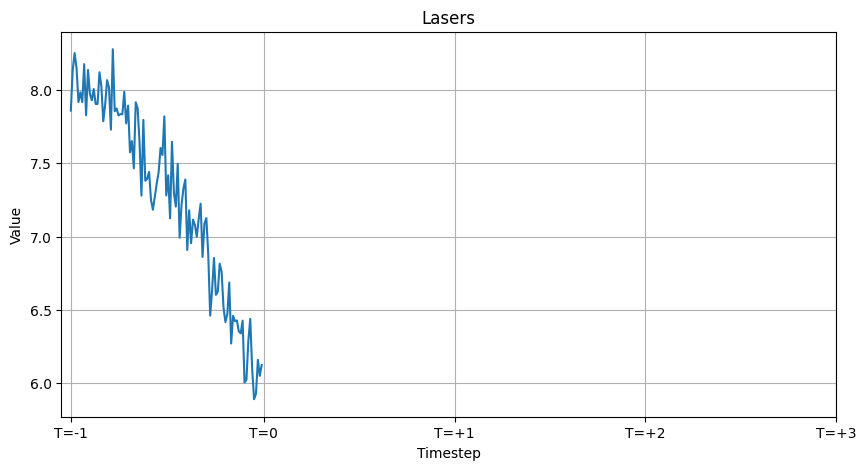

In [3]:
dr = DataReader("./data/Bundle1")
dr.read_data()
dr.plot()
data = dr.get_data()
assert len(data.keys()) == 20

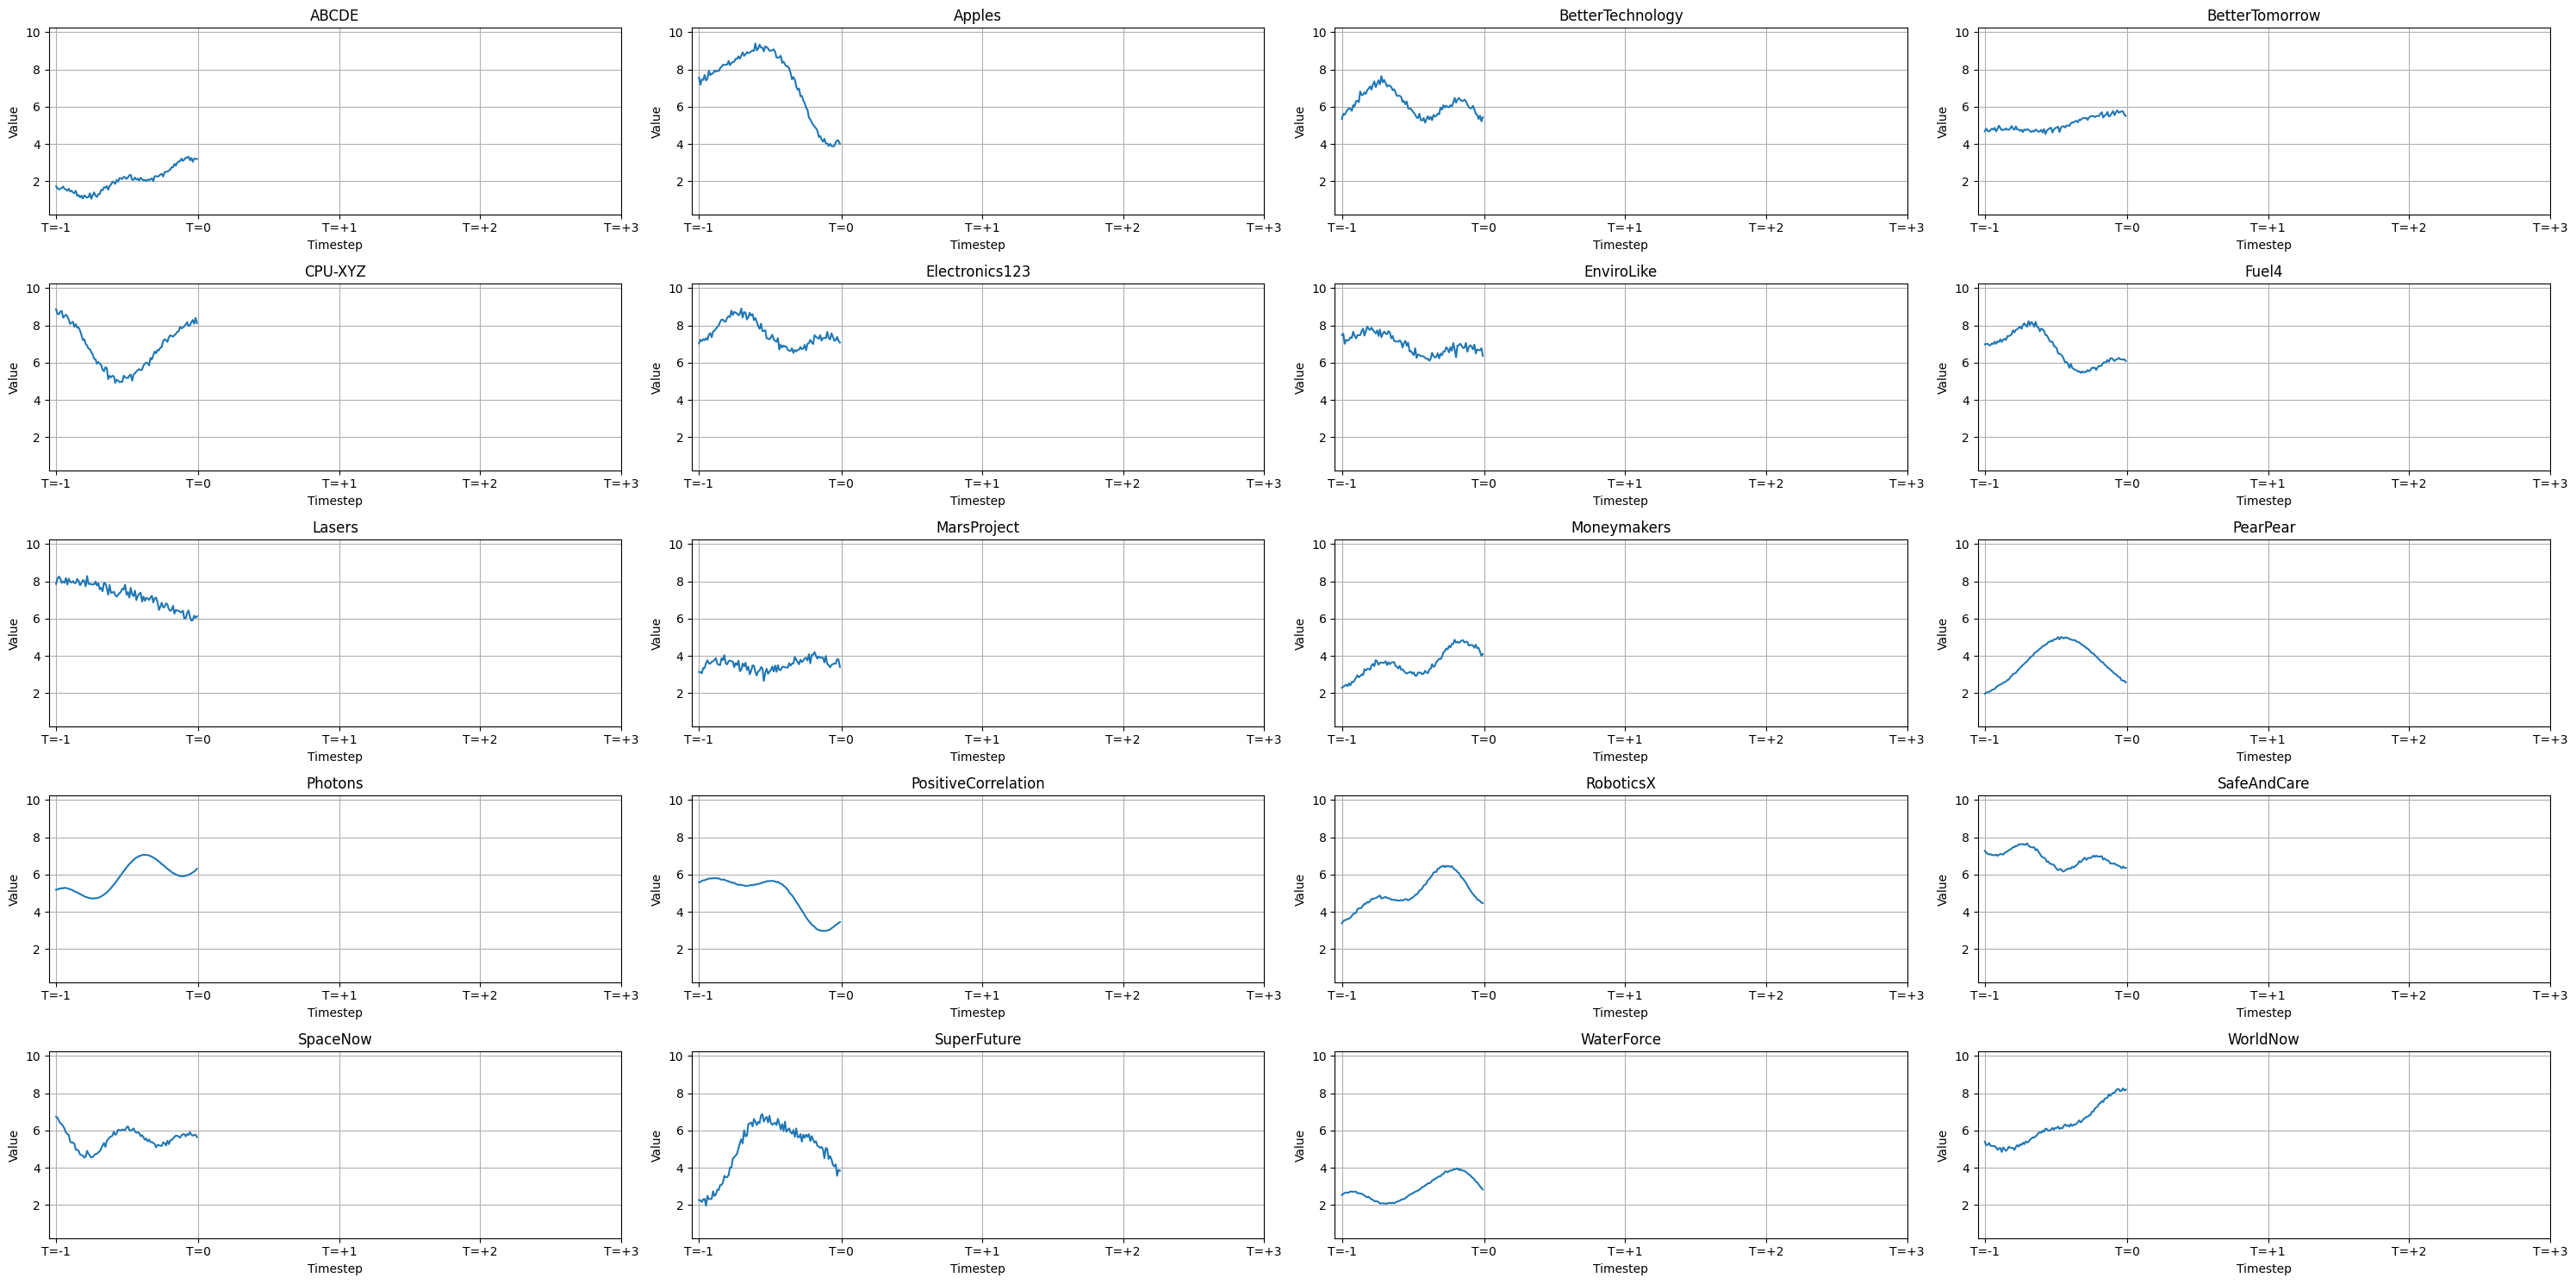

In [4]:
dr.plot_all(figsize=(30, 15), normalized_y=True)

## Regression Algorithms

### Linear Regression

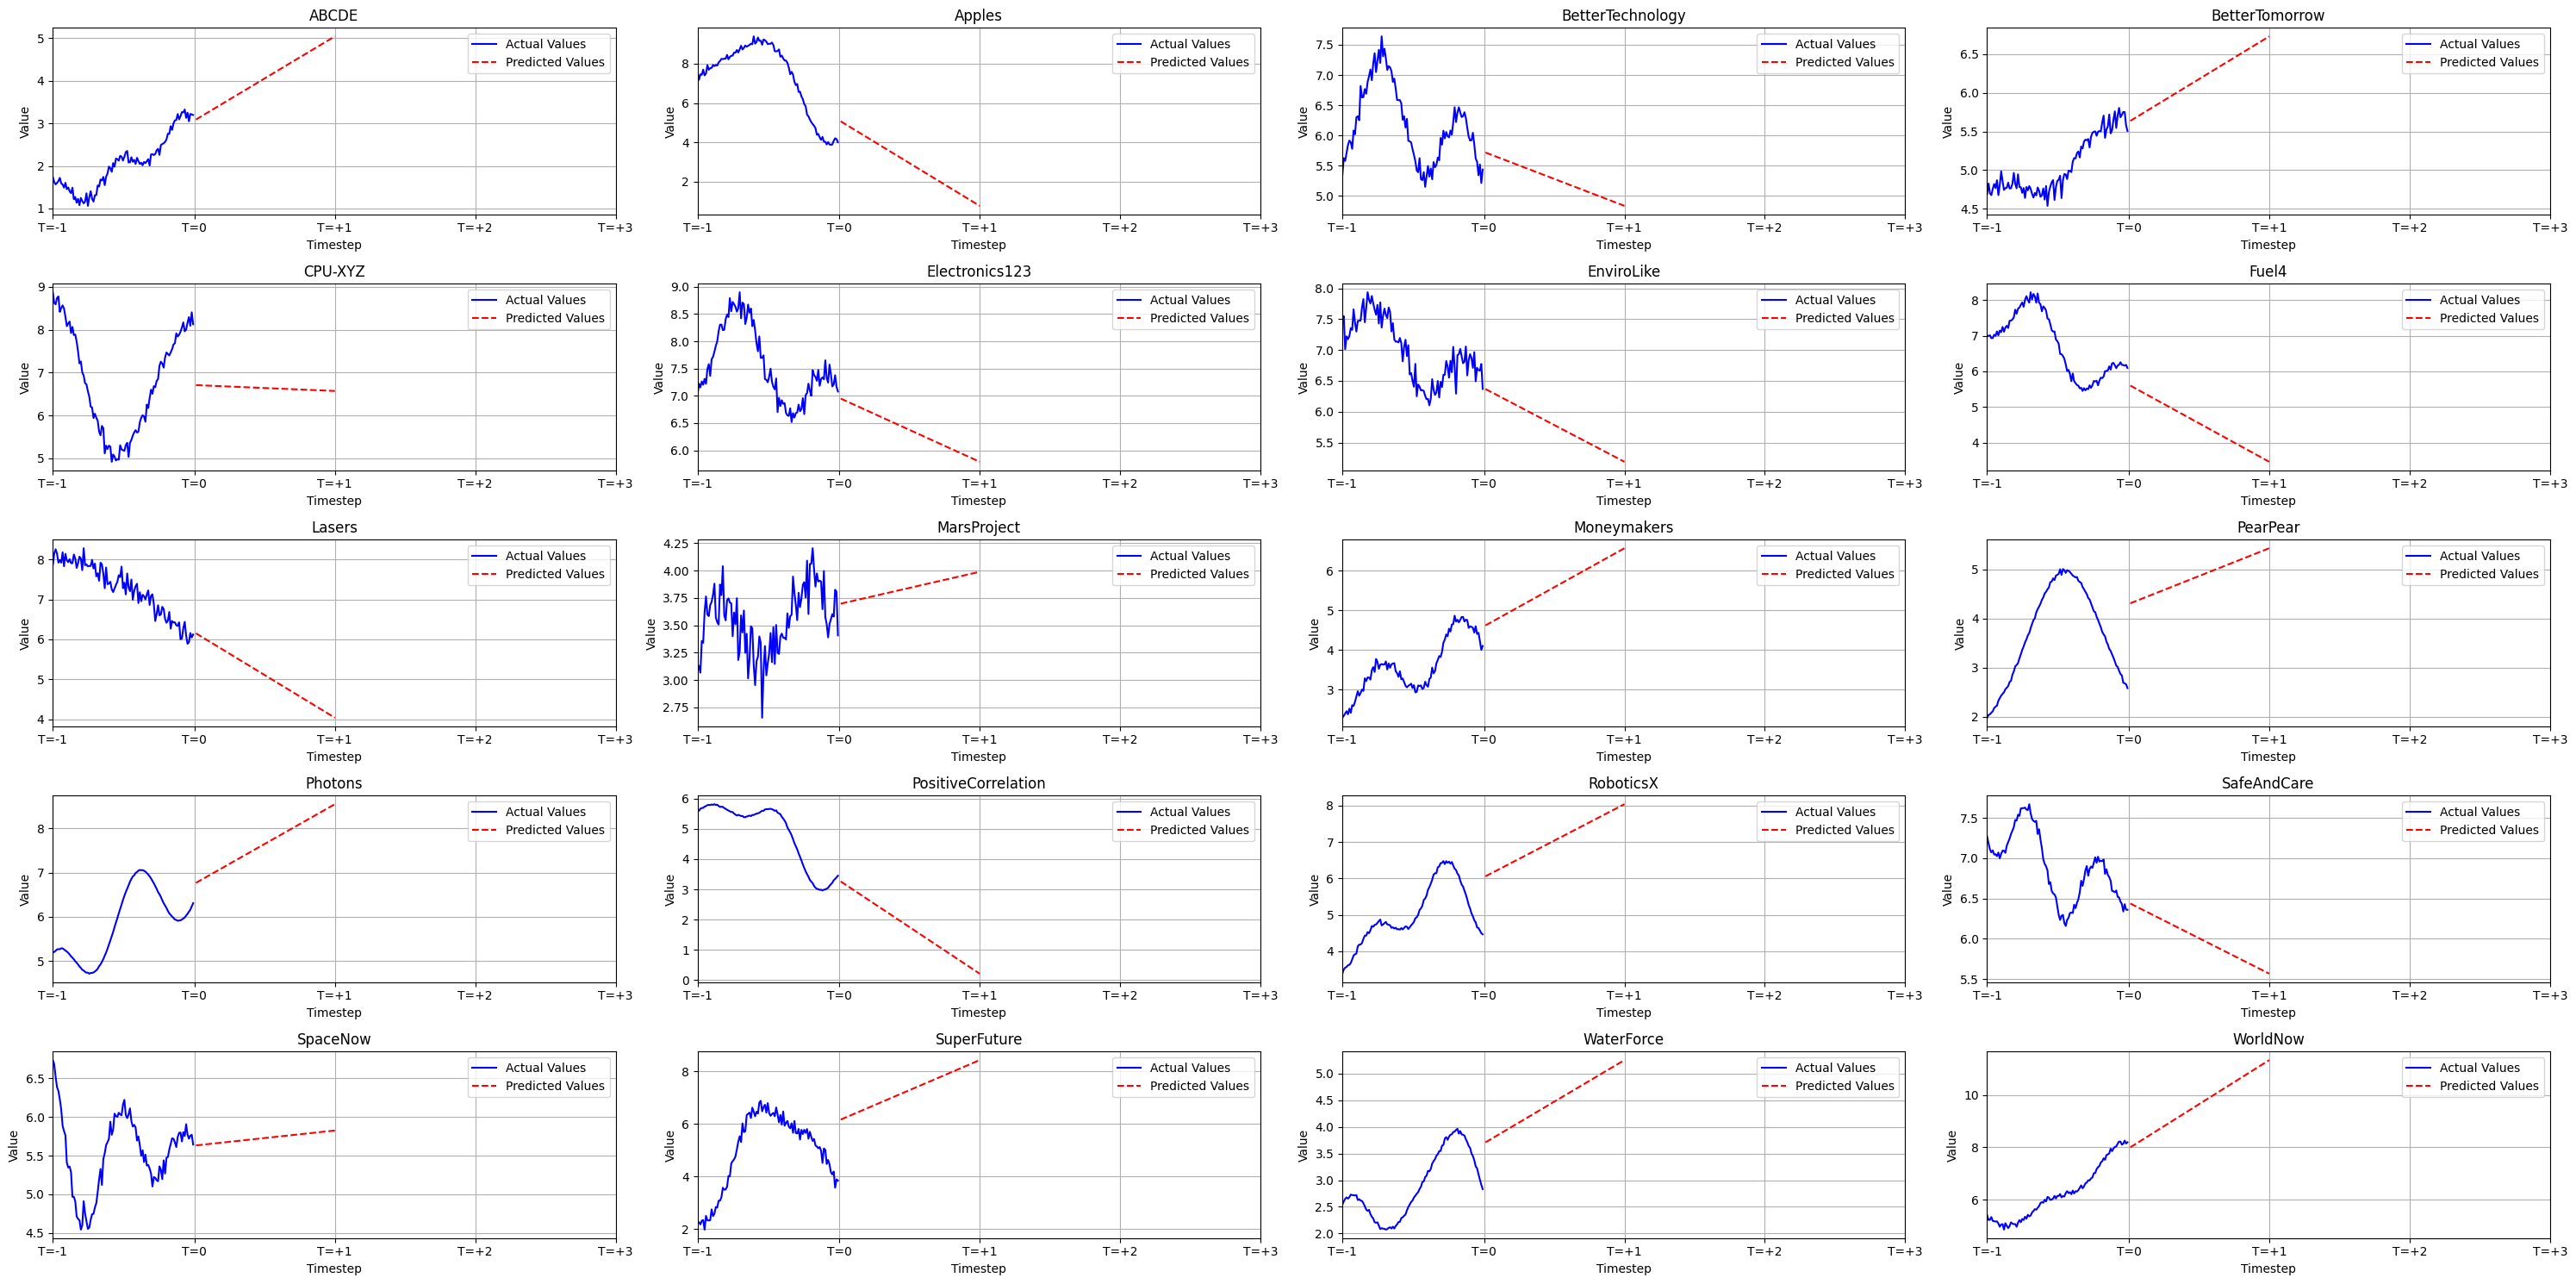

In [5]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_linear()
linear_predictions = RMC.predict_linear()
RMC.plot_predictions(val_range=201, predictions=linear_predictions, figsize=(30, 15))

### Sinusoidal Regression

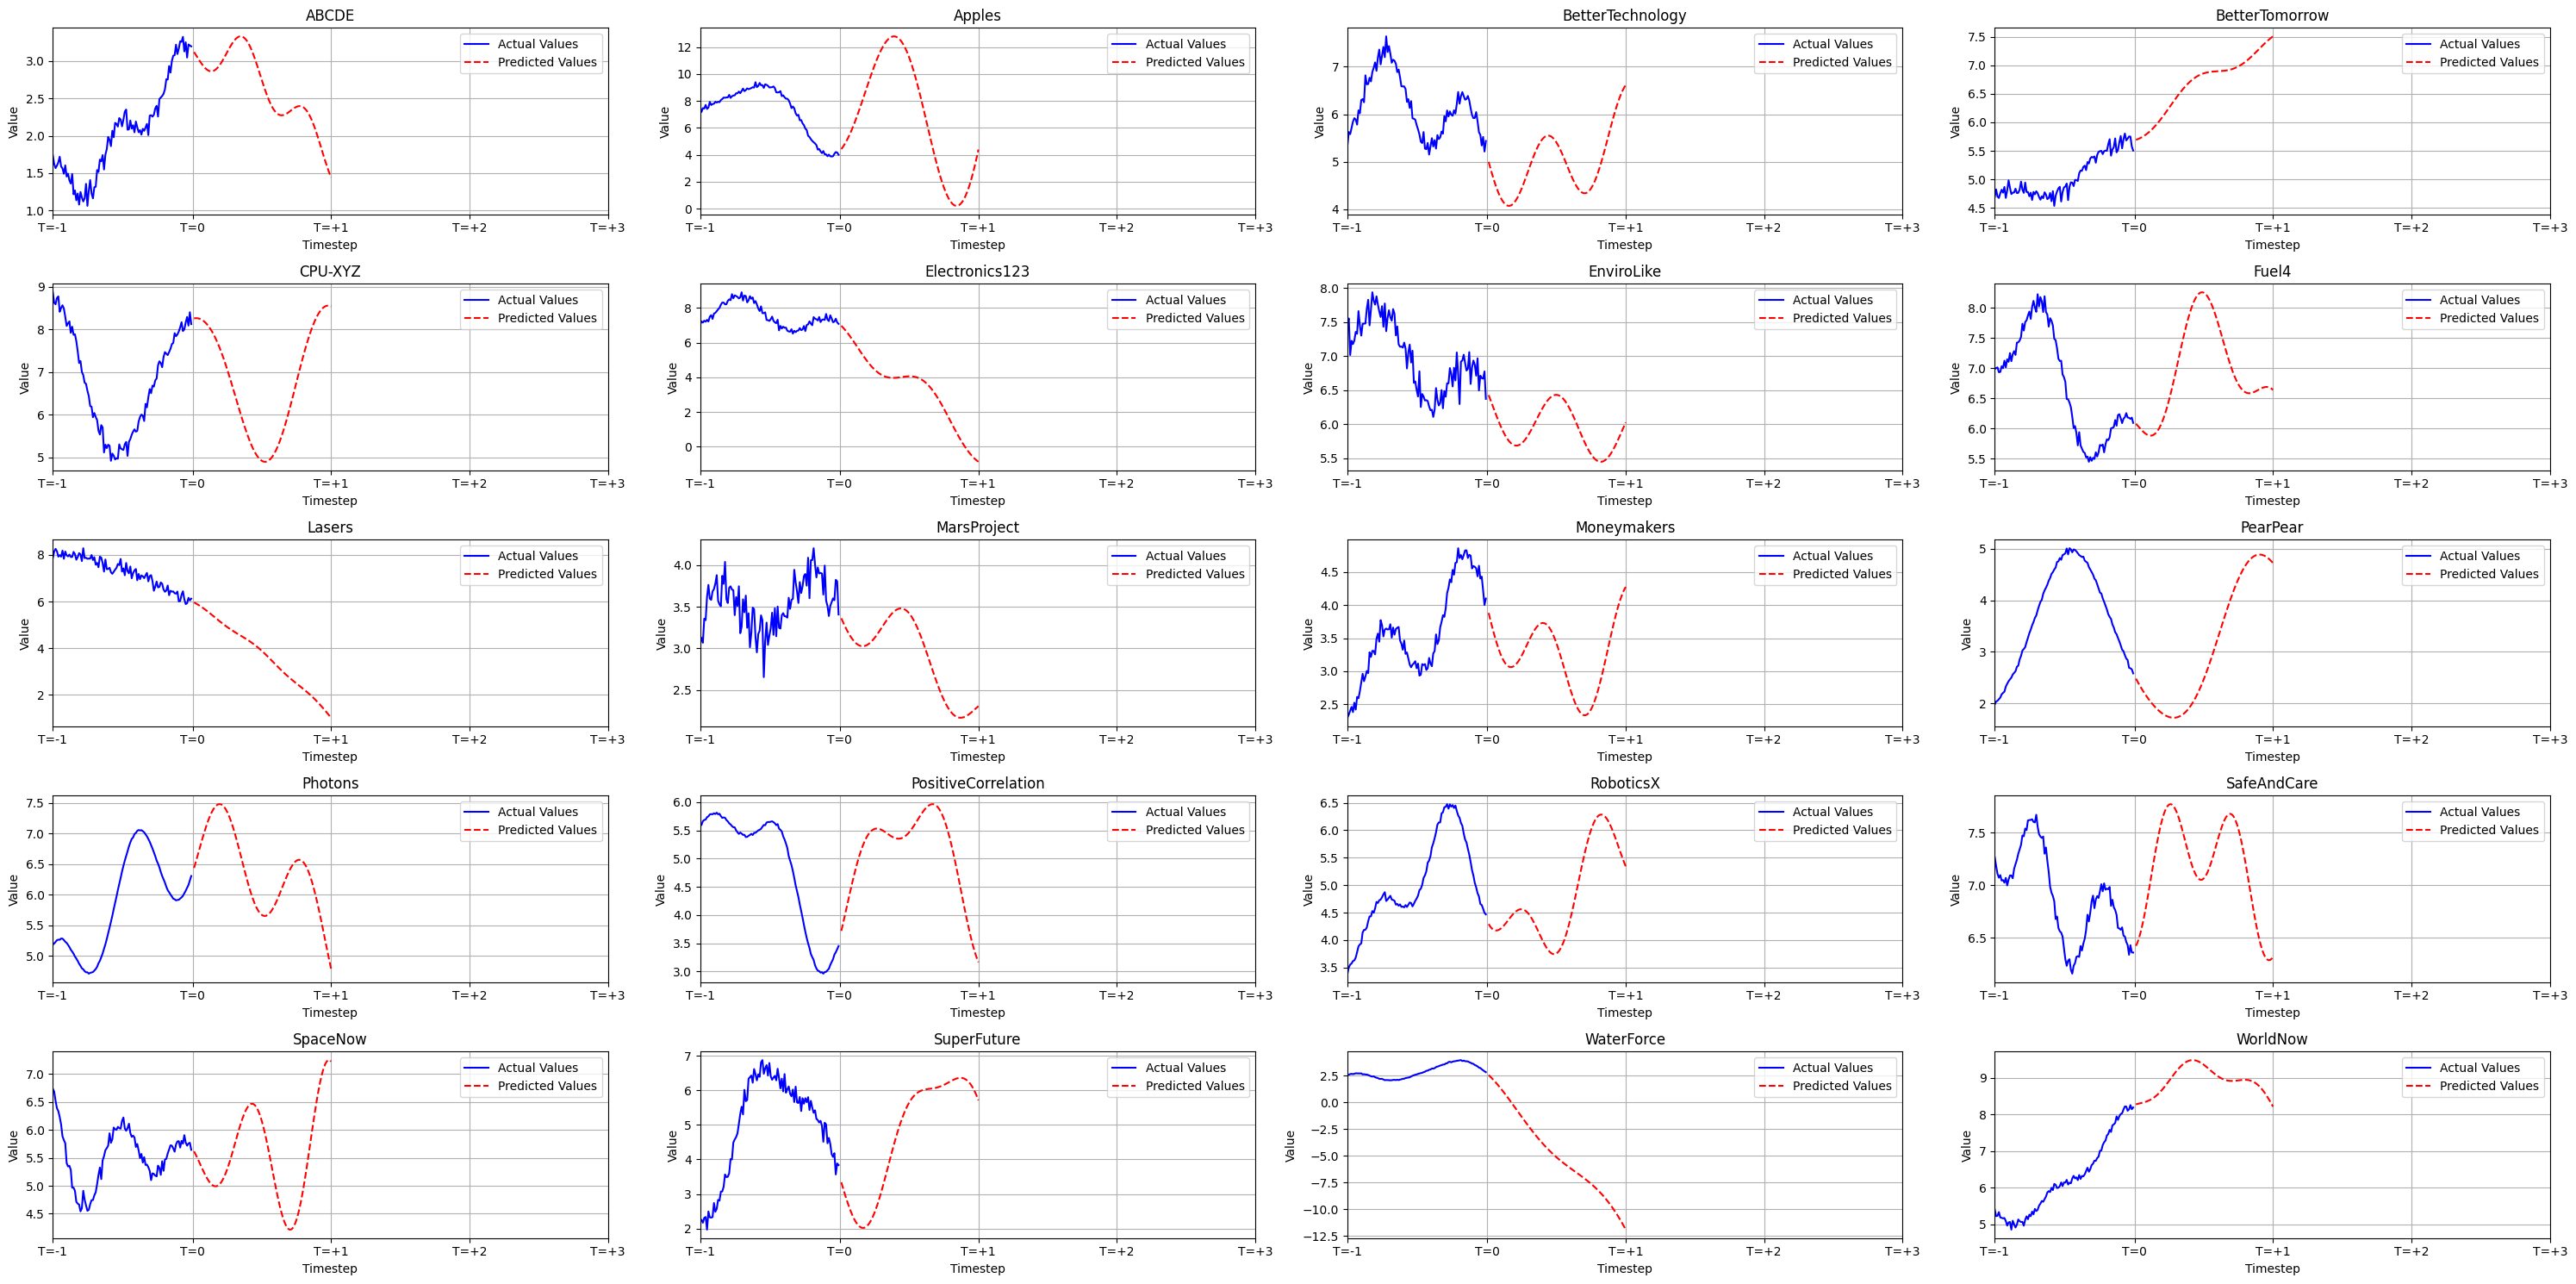

In [6]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_sinusoidal()
sinusoidal_predictions = RMC.predict_sinusoidal()
RMC.plot_predictions(val_range=201, predictions=sinusoidal_predictions, figsize=(30, 15))

### Sinusoidal + Linear Regression

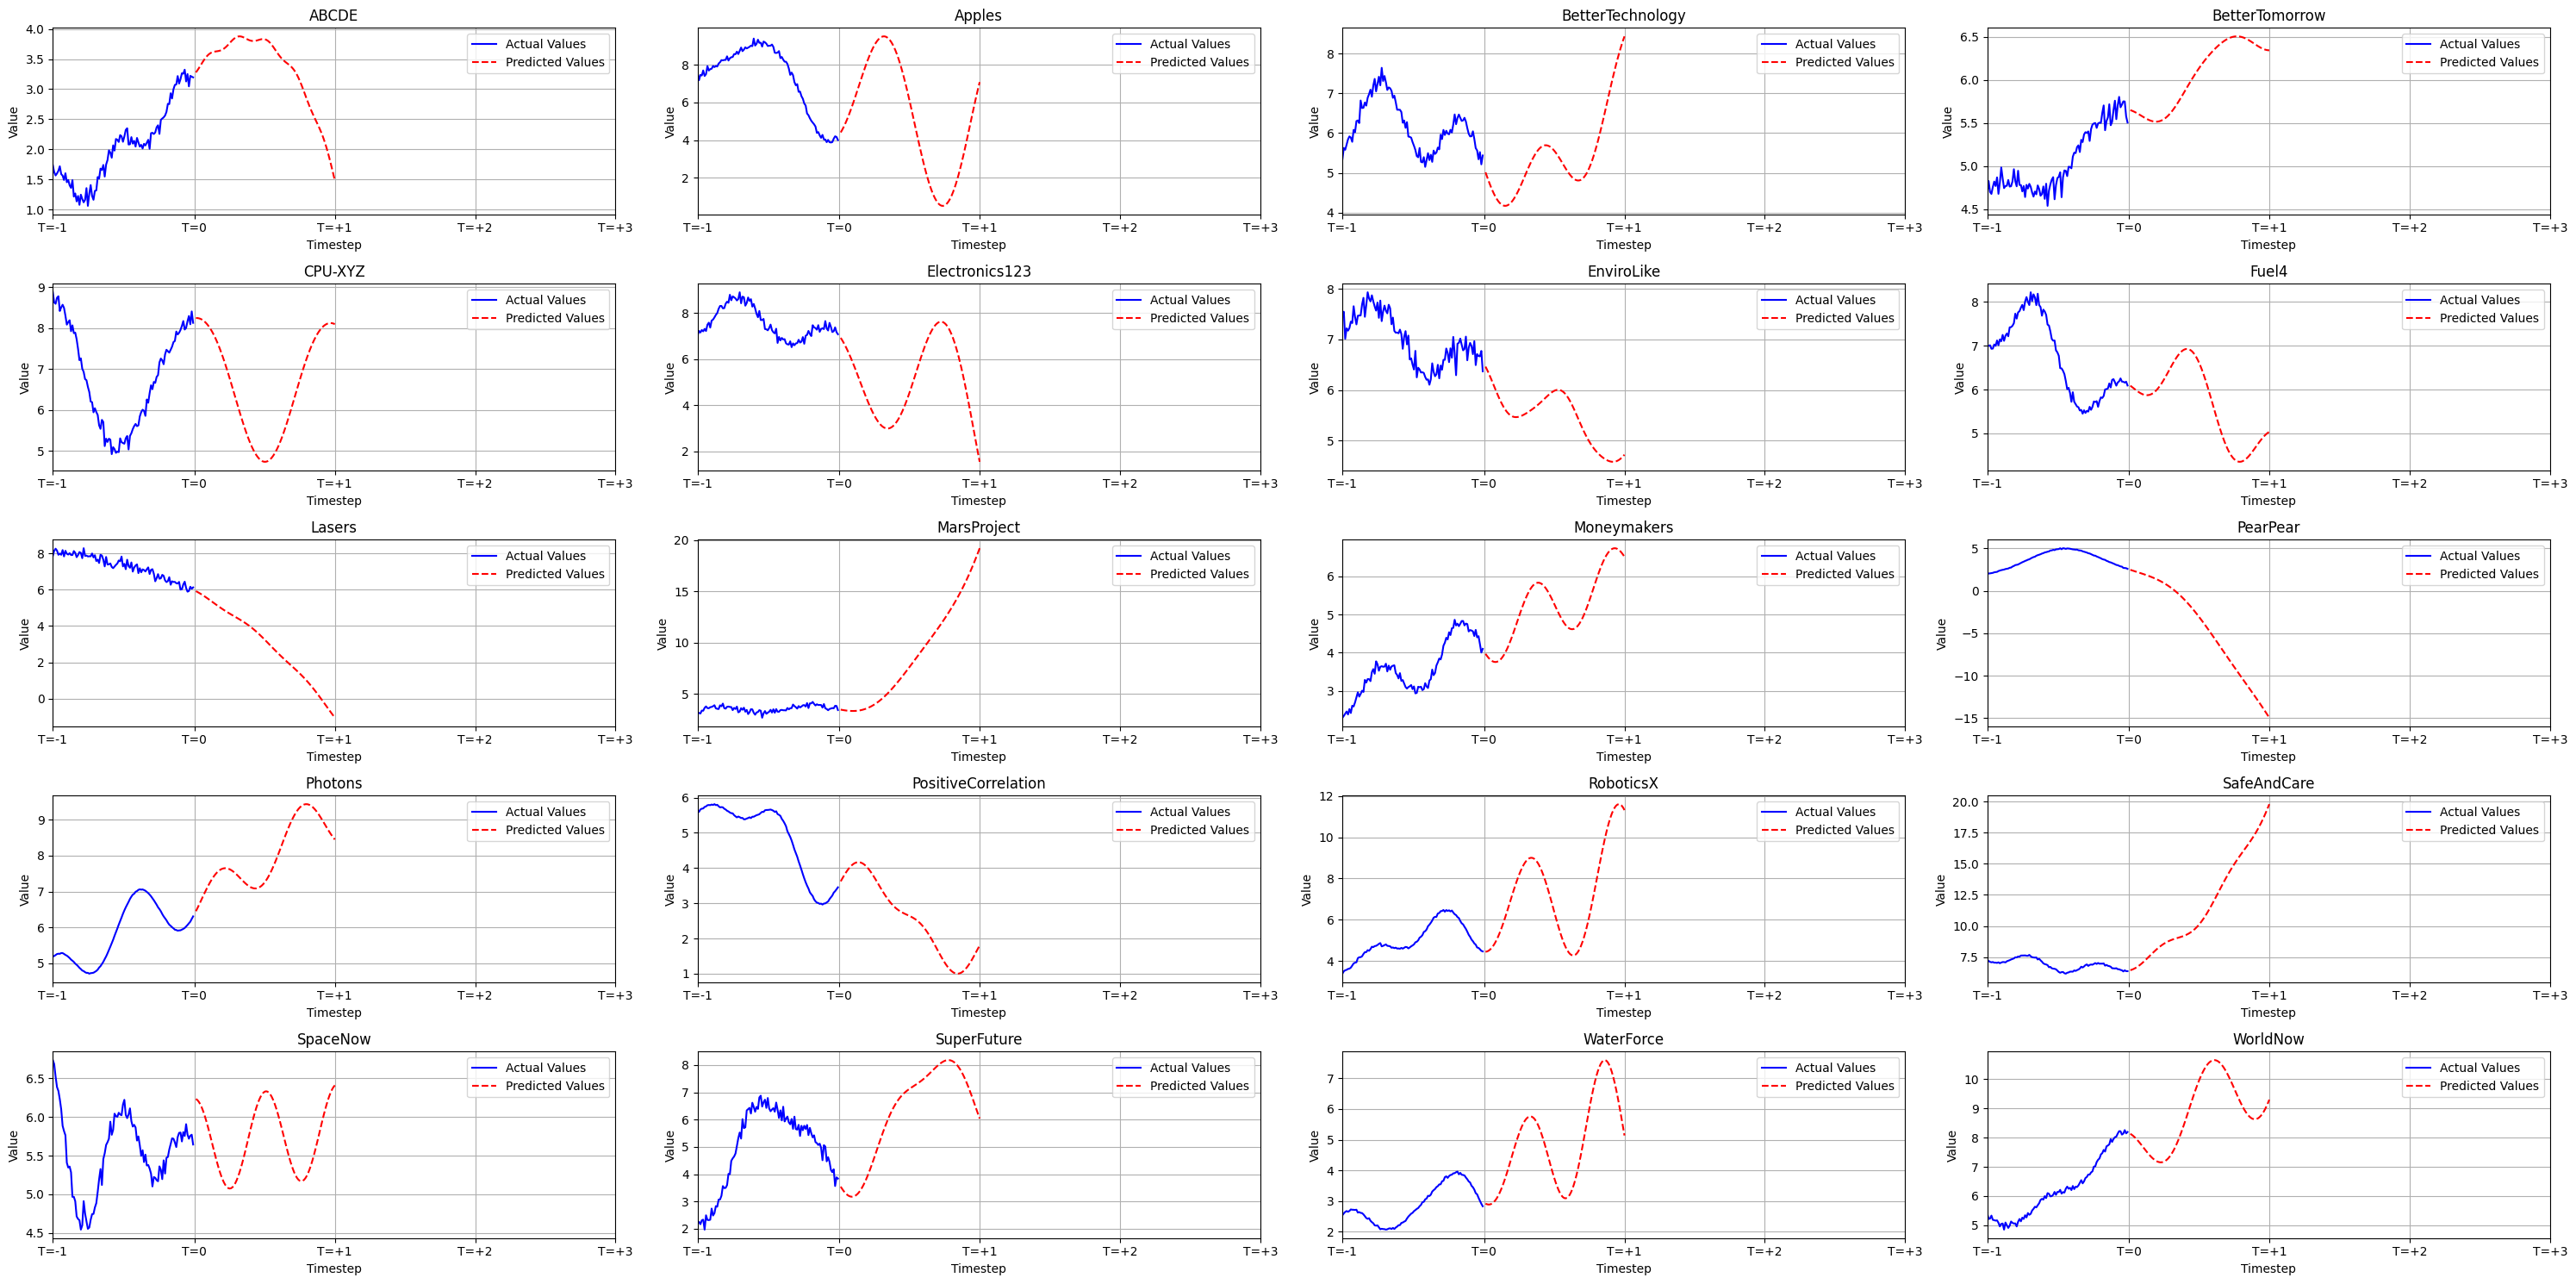

In [7]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_complex_sinusoidal()
complex_sinusoidal_predictions = RMC.predict_complex_sinusoidal()
RMC.plot_predictions(val_range=201, predictions=complex_sinusoidal_predictions, figsize=(30, 15))

## ARIMA

Lags for company = ABCDE


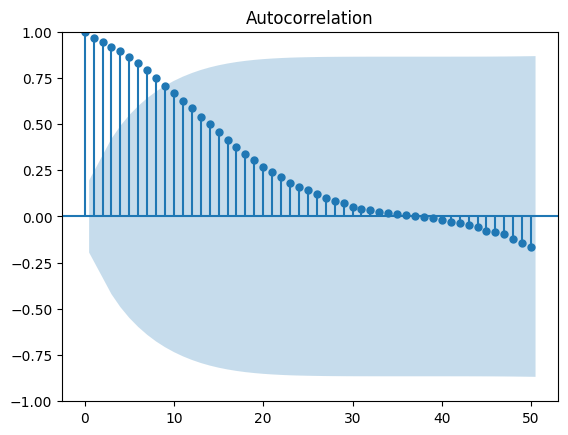

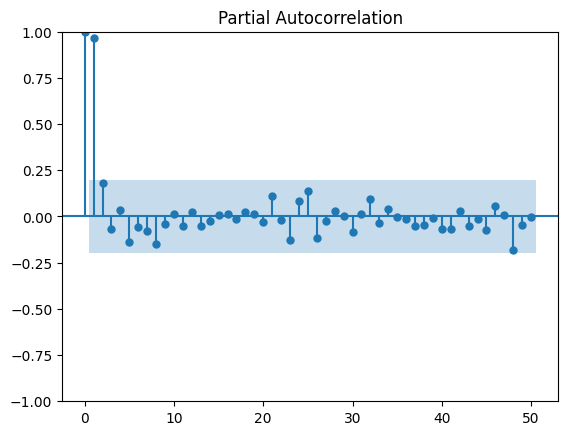

Lags for company = Apples


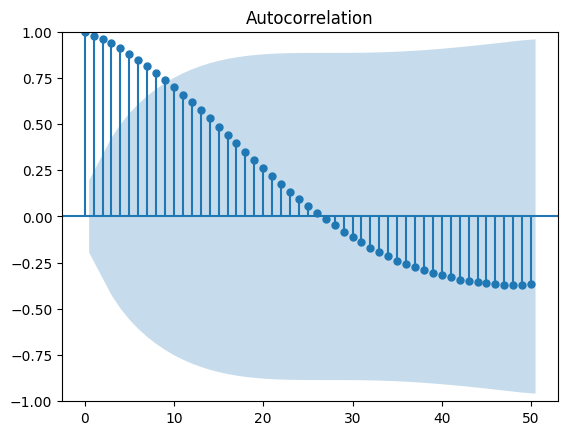

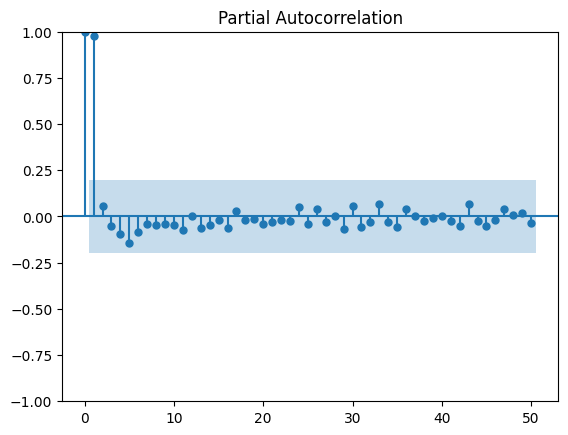

Lags for company = BetterTechnology


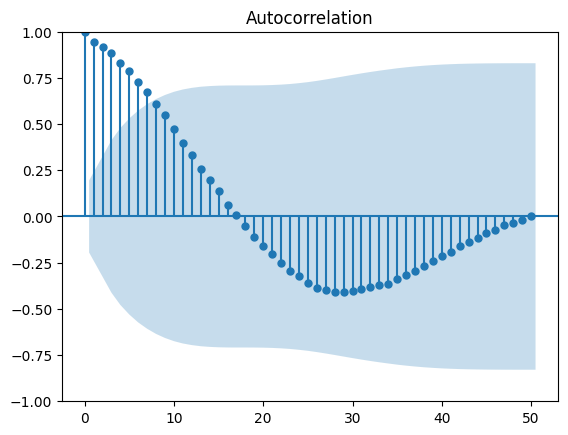

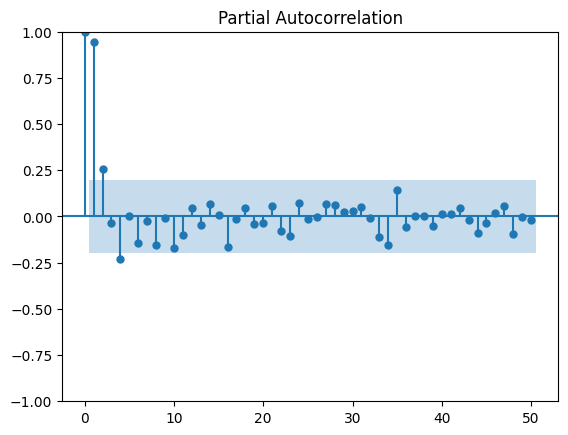

Lags for company = BetterTomorrow


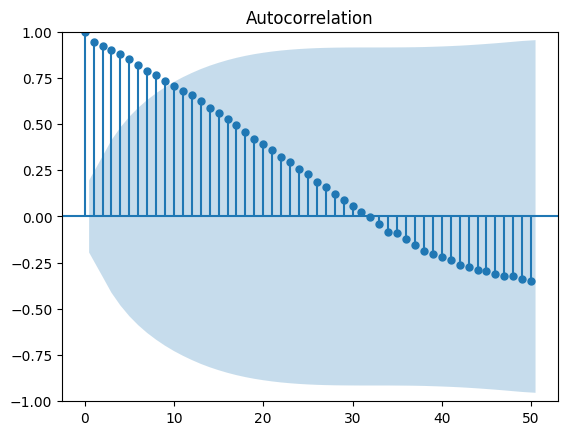

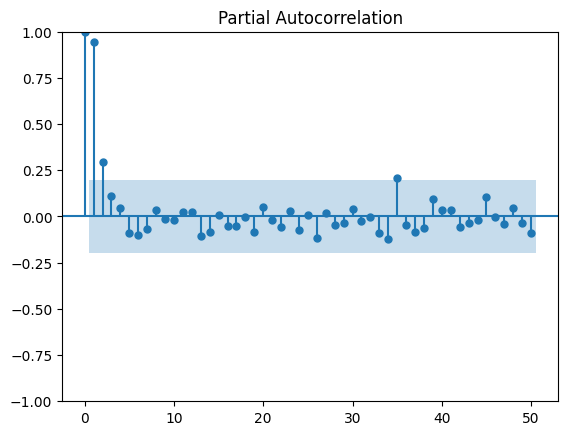

Lags for company = CPU-XYZ


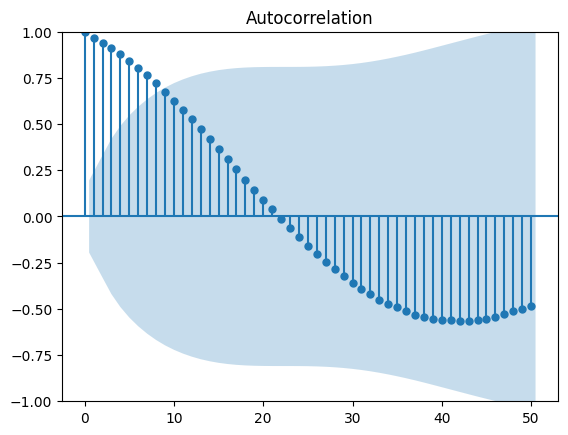

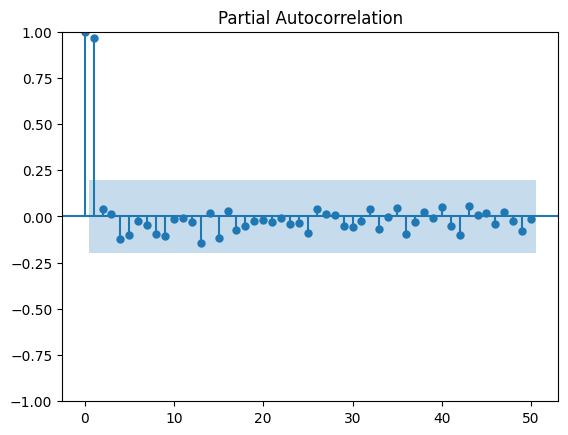

Lags for company = Electronics123


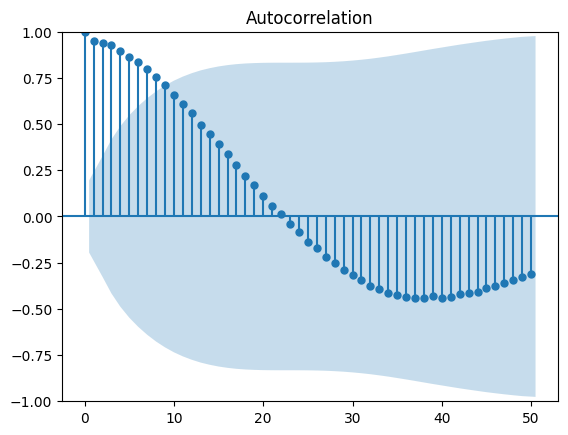

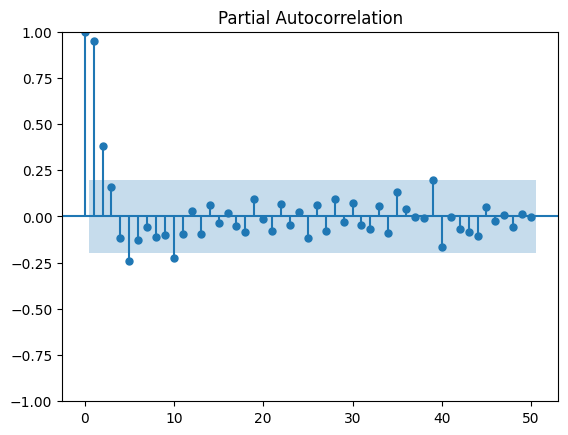

Lags for company = EnviroLike


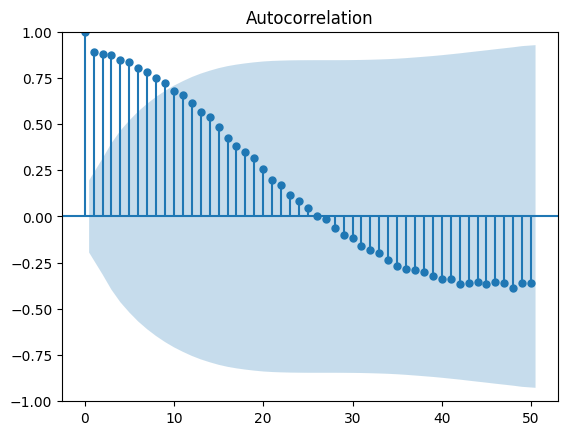

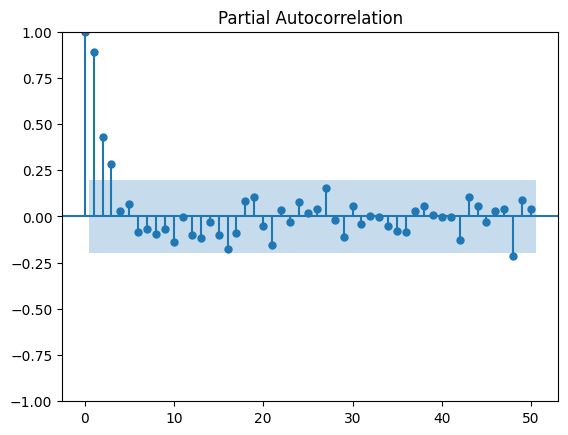

Lags for company = Fuel4


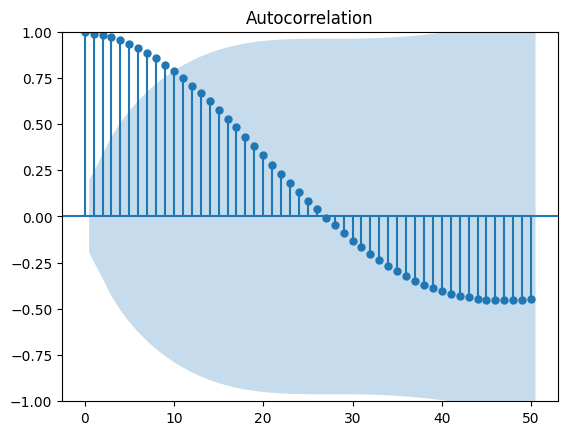

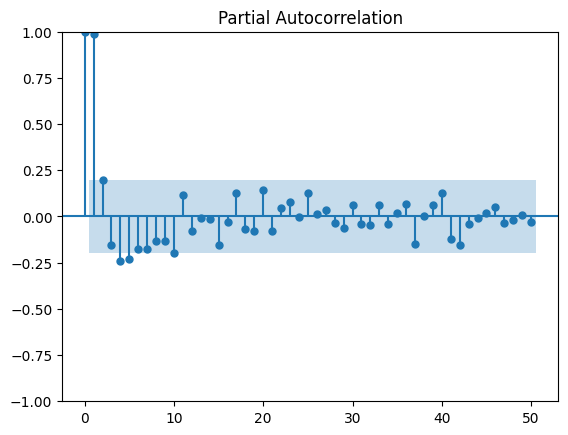

Lags for company = Lasers


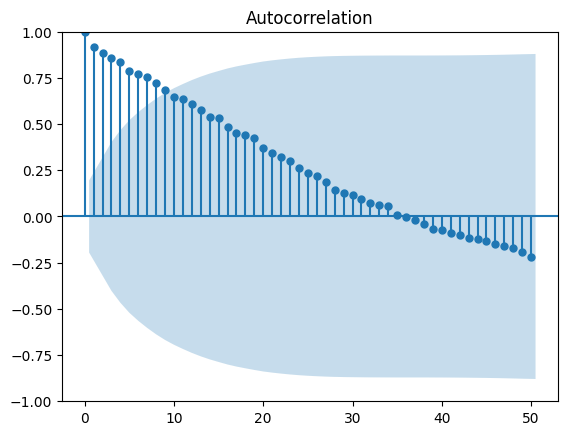

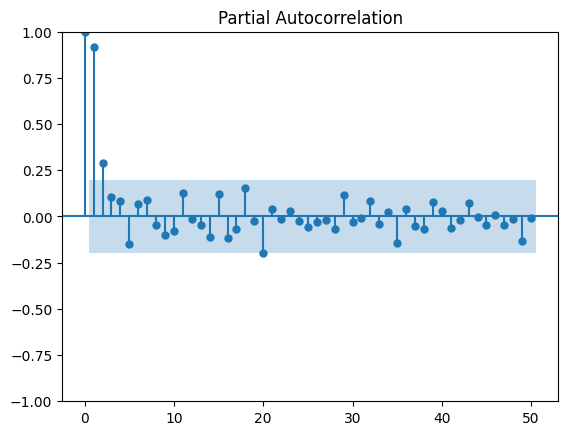

Lags for company = MarsProject


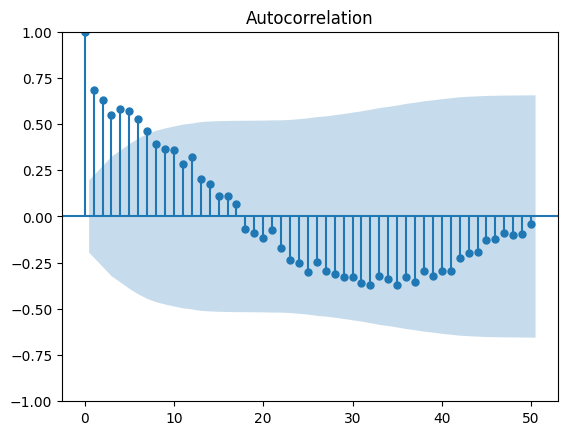

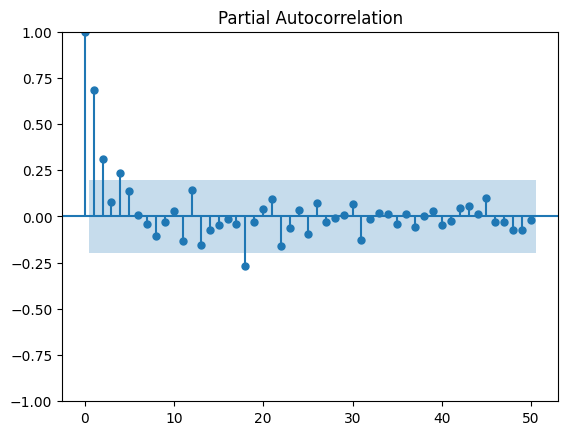

Lags for company = Moneymakers


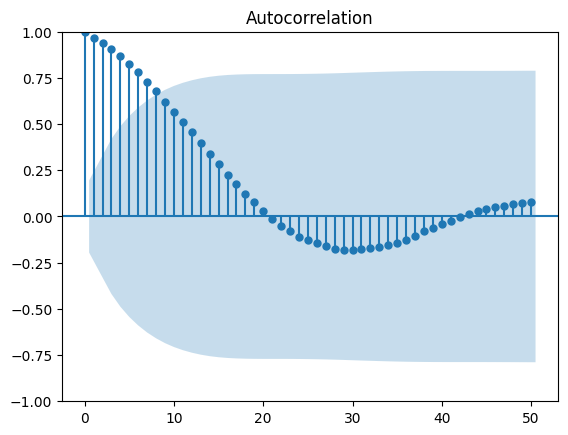

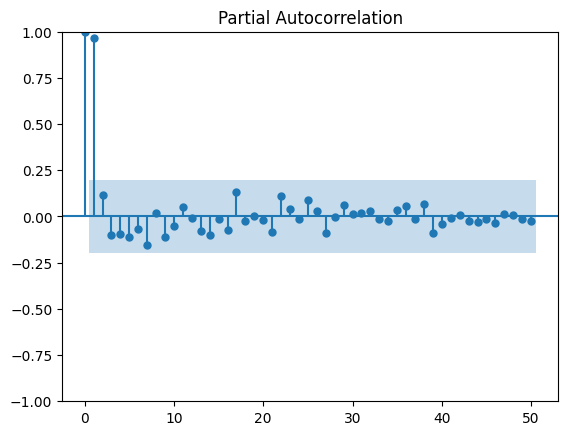

Lags for company = PearPear


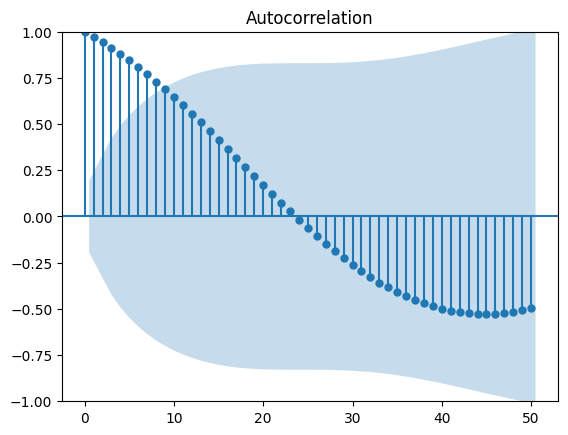

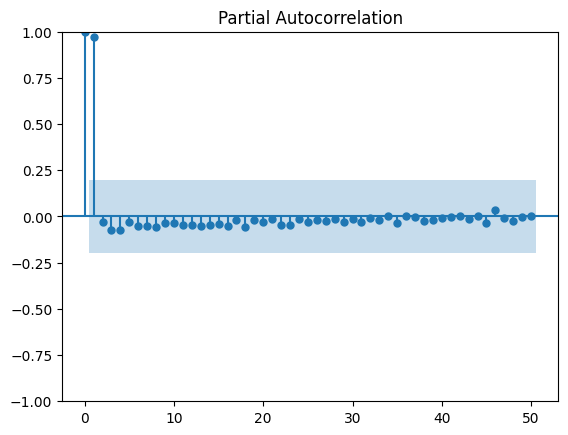

Lags for company = Photons


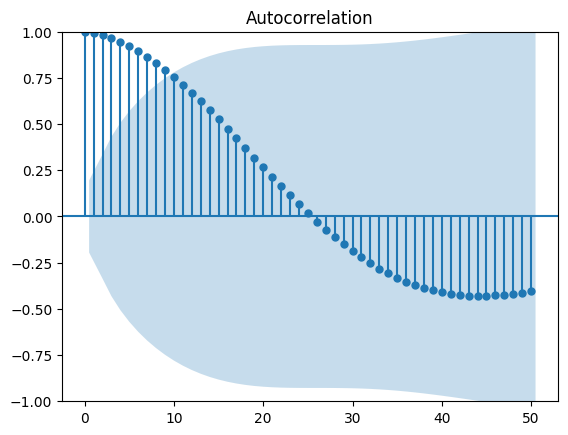

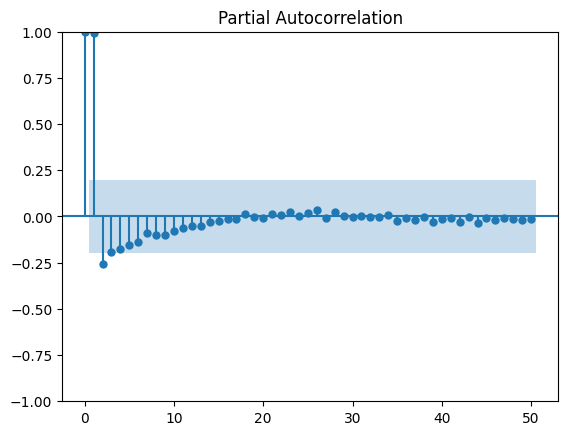

Lags for company = PositiveCorrelation


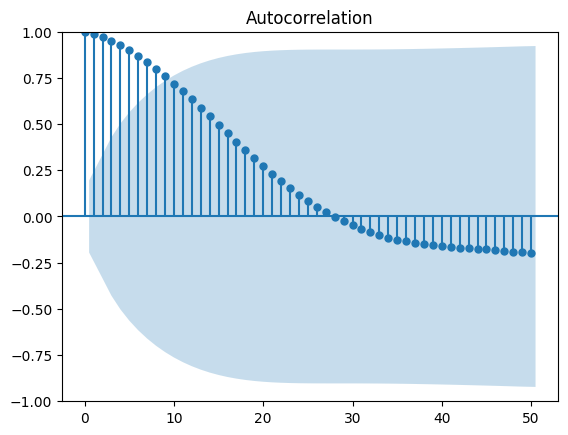

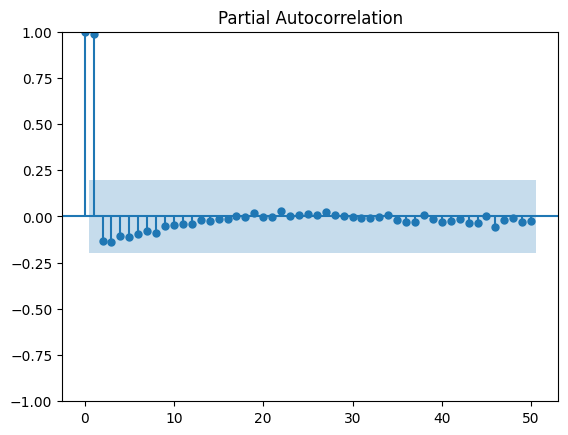

Lags for company = RoboticsX


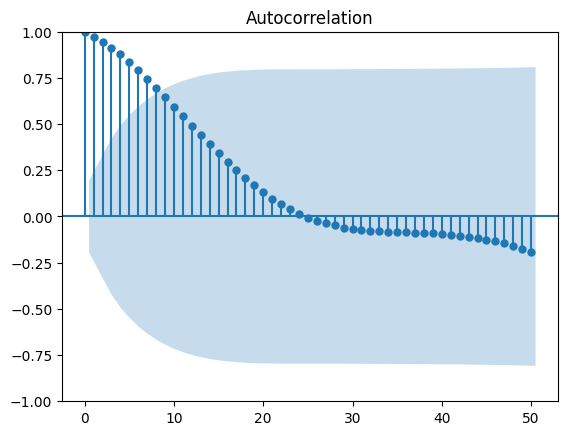

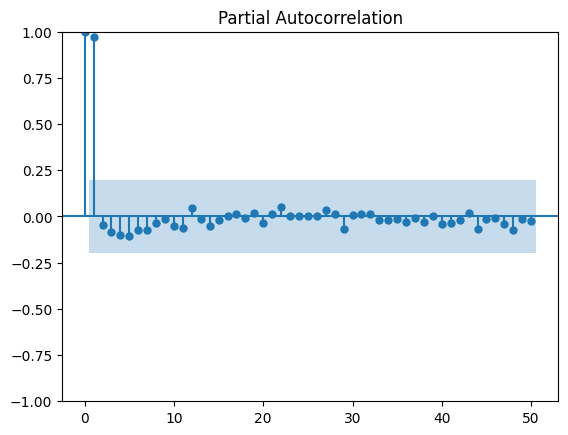

Lags for company = SafeAndCare


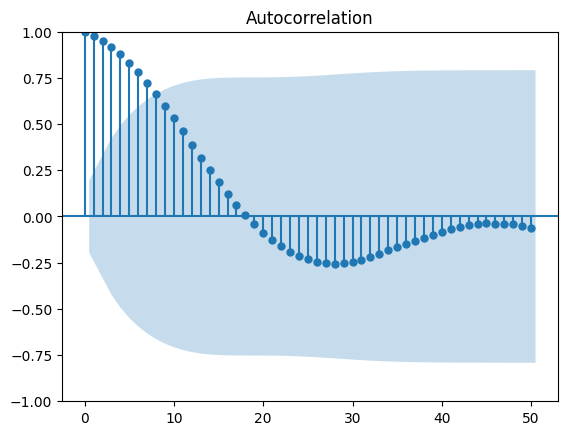

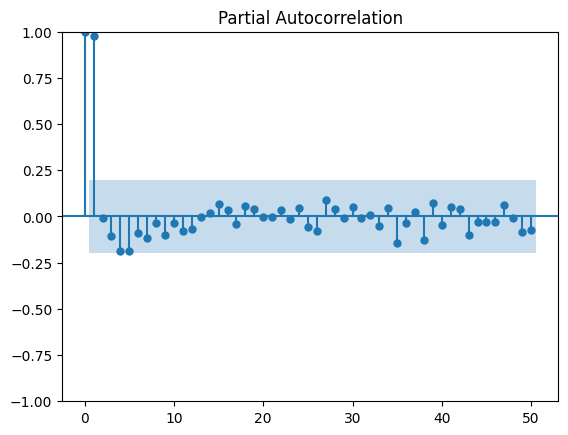

Lags for company = SpaceNow


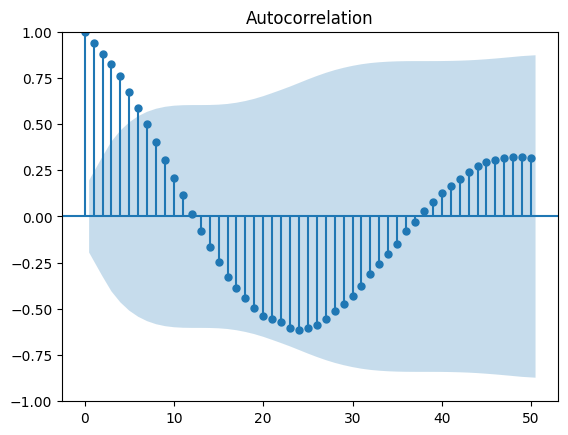

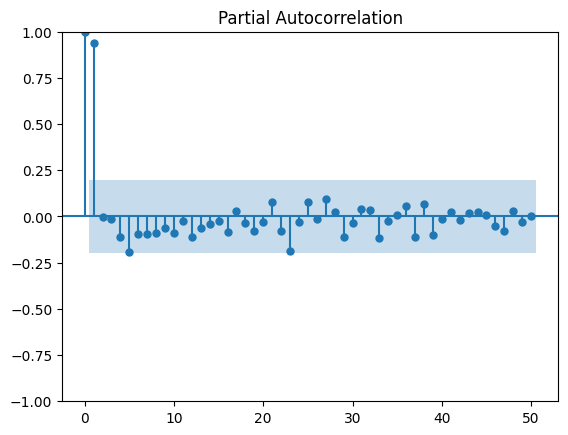

Lags for company = SuperFuture


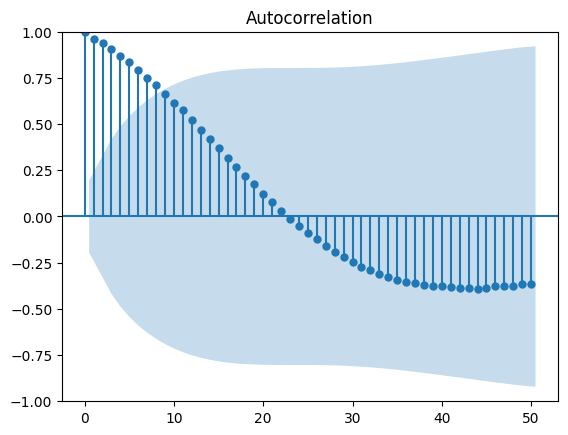

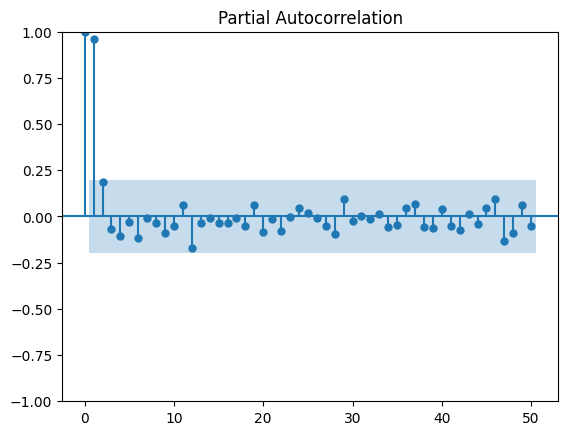

Lags for company = WaterForce


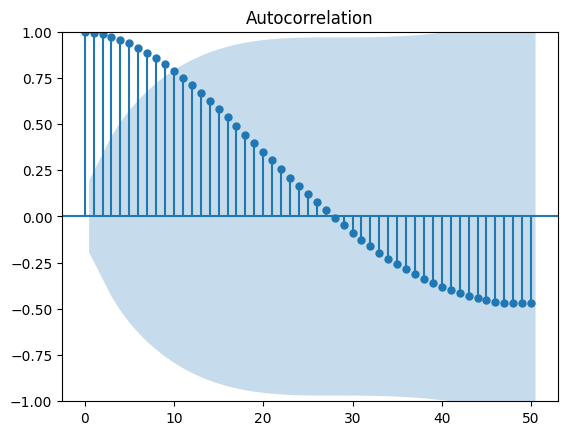

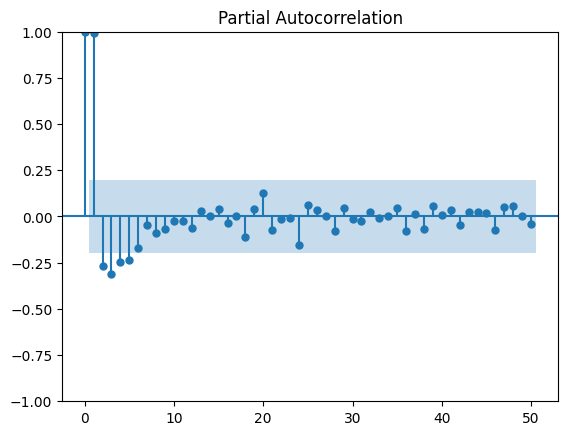

Lags for company = WorldNow


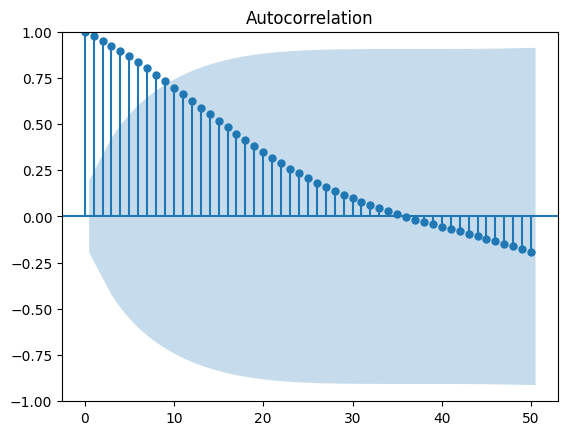

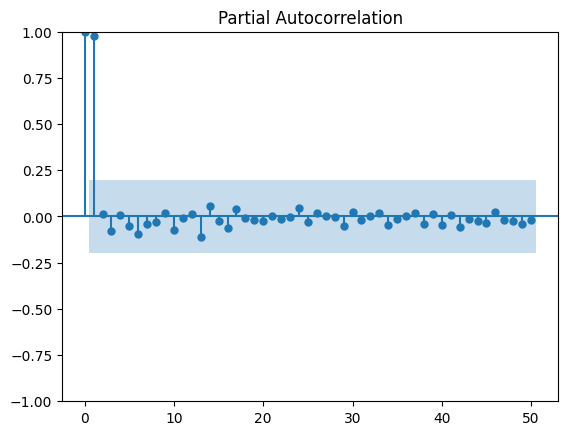

d:\MOO\MOO_env\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\MOO\MOO_env\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
d:\MOO\MOO_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


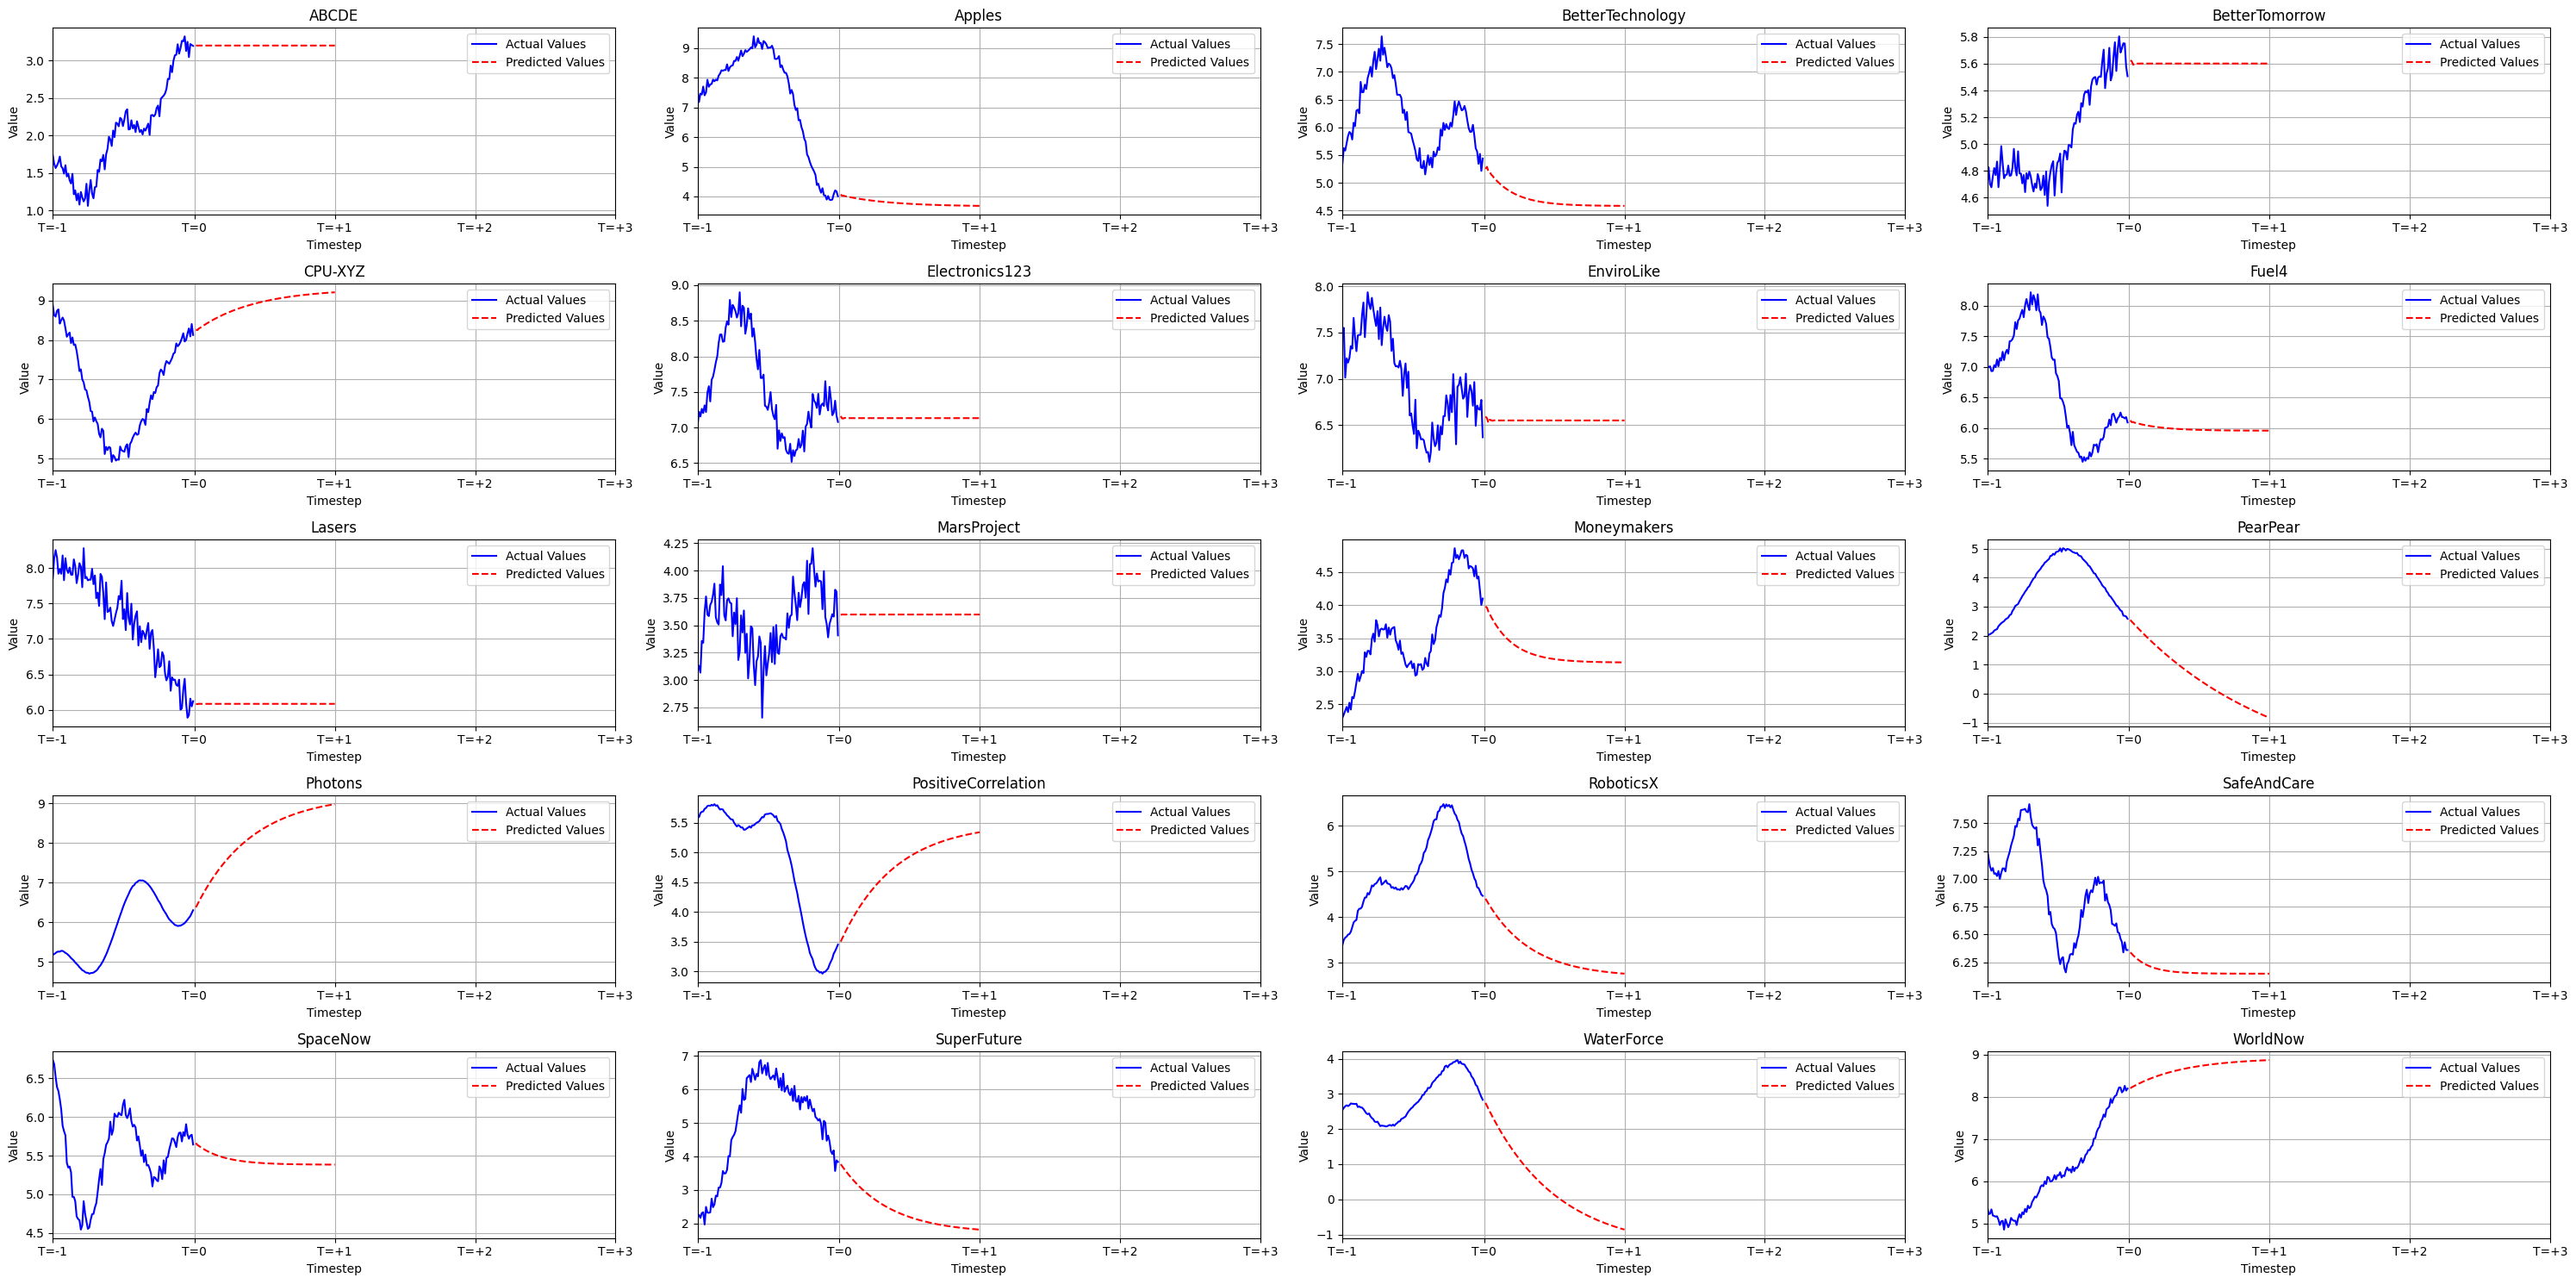

In [8]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.plot_arima_lags(max_lags=50)
RMC.train_arima(p=2, d=1, q=1)
ARIMA_predictions = RMC.predict_arima()
RMC.plot_predictions(val_range=201, predictions=ARIMA_predictions, figsize=(30, 15))

### XGBoost

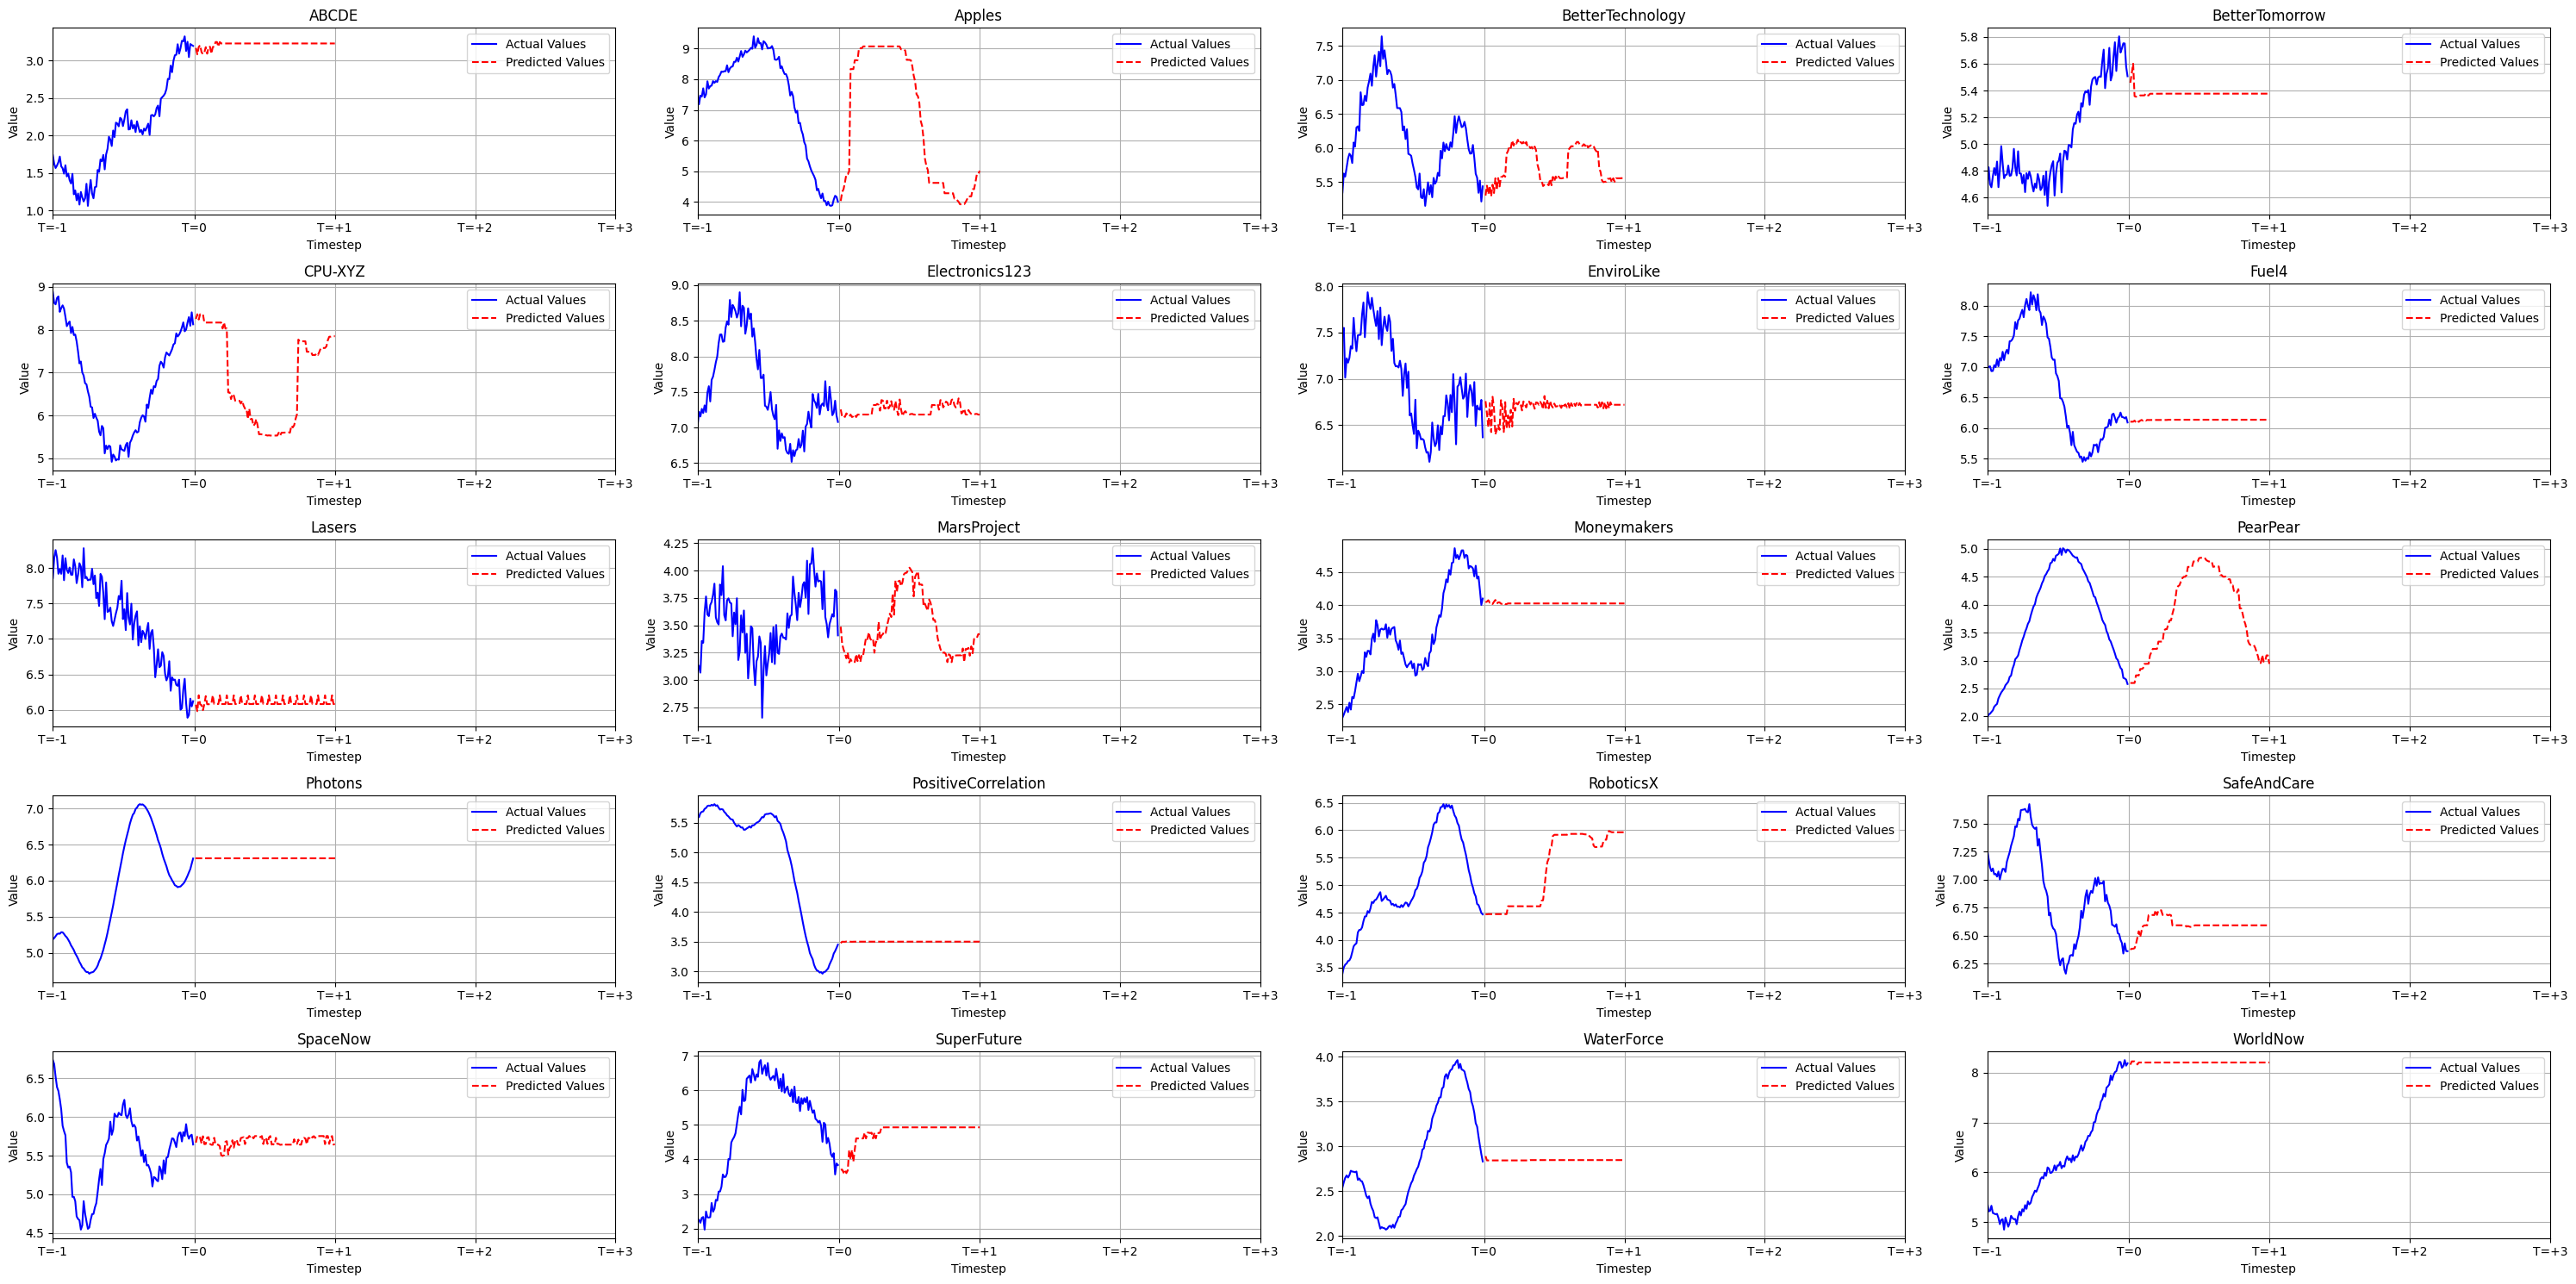

In [9]:
RMC = RegressionModelsCombined(data, window_size=50)
RMC.create_X_y_windows()
RMC.train_xgboost()
XGBoost_predictions = RMC.predict_xgboost()
RMC.plot_predictions(val_range=201, predictions=XGBoost_predictions, figsize=(30, 15))

### NODE

Using device: cpu
Company: ABCDE, Epoch 0, Loss: 8.833486557006836
Company: ABCDE, Epoch 100, Loss: 0.05702627822756767
Company: ABCDE, Epoch 200, Loss: 0.03904247656464577
Company: Apples, Epoch 0, Loss: 96.06742095947266
Company: Apples, Epoch 100, Loss: 0.6325602531433105
Company: Apples, Epoch 200, Loss: 0.09874632209539413
Company: BetterTechnology, Epoch 0, Loss: 18.803682327270508
Company: BetterTechnology, Epoch 100, Loss: 0.3283359706401825
Company: BetterTechnology, Epoch 200, Loss: 0.3272753059864044
Company: BetterTomorrow, Epoch 0, Loss: 26.394411087036133
Company: BetterTomorrow, Epoch 100, Loss: 0.033493928611278534
Company: BetterTomorrow, Epoch 200, Loss: 0.028864022344350815
Company: CPU-XYZ, Epoch 0, Loss: 3.1396379470825195
Company: CPU-XYZ, Epoch 100, Loss: 0.0375826470553875
Company: CPU-XYZ, Epoch 200, Loss: 0.029339201748371124
Company: Electronics123, Epoch 0, Loss: 39.84669494628906
Company: Electronics123, Epoch 100, Loss: 0.30516287684440613
Company: Electro

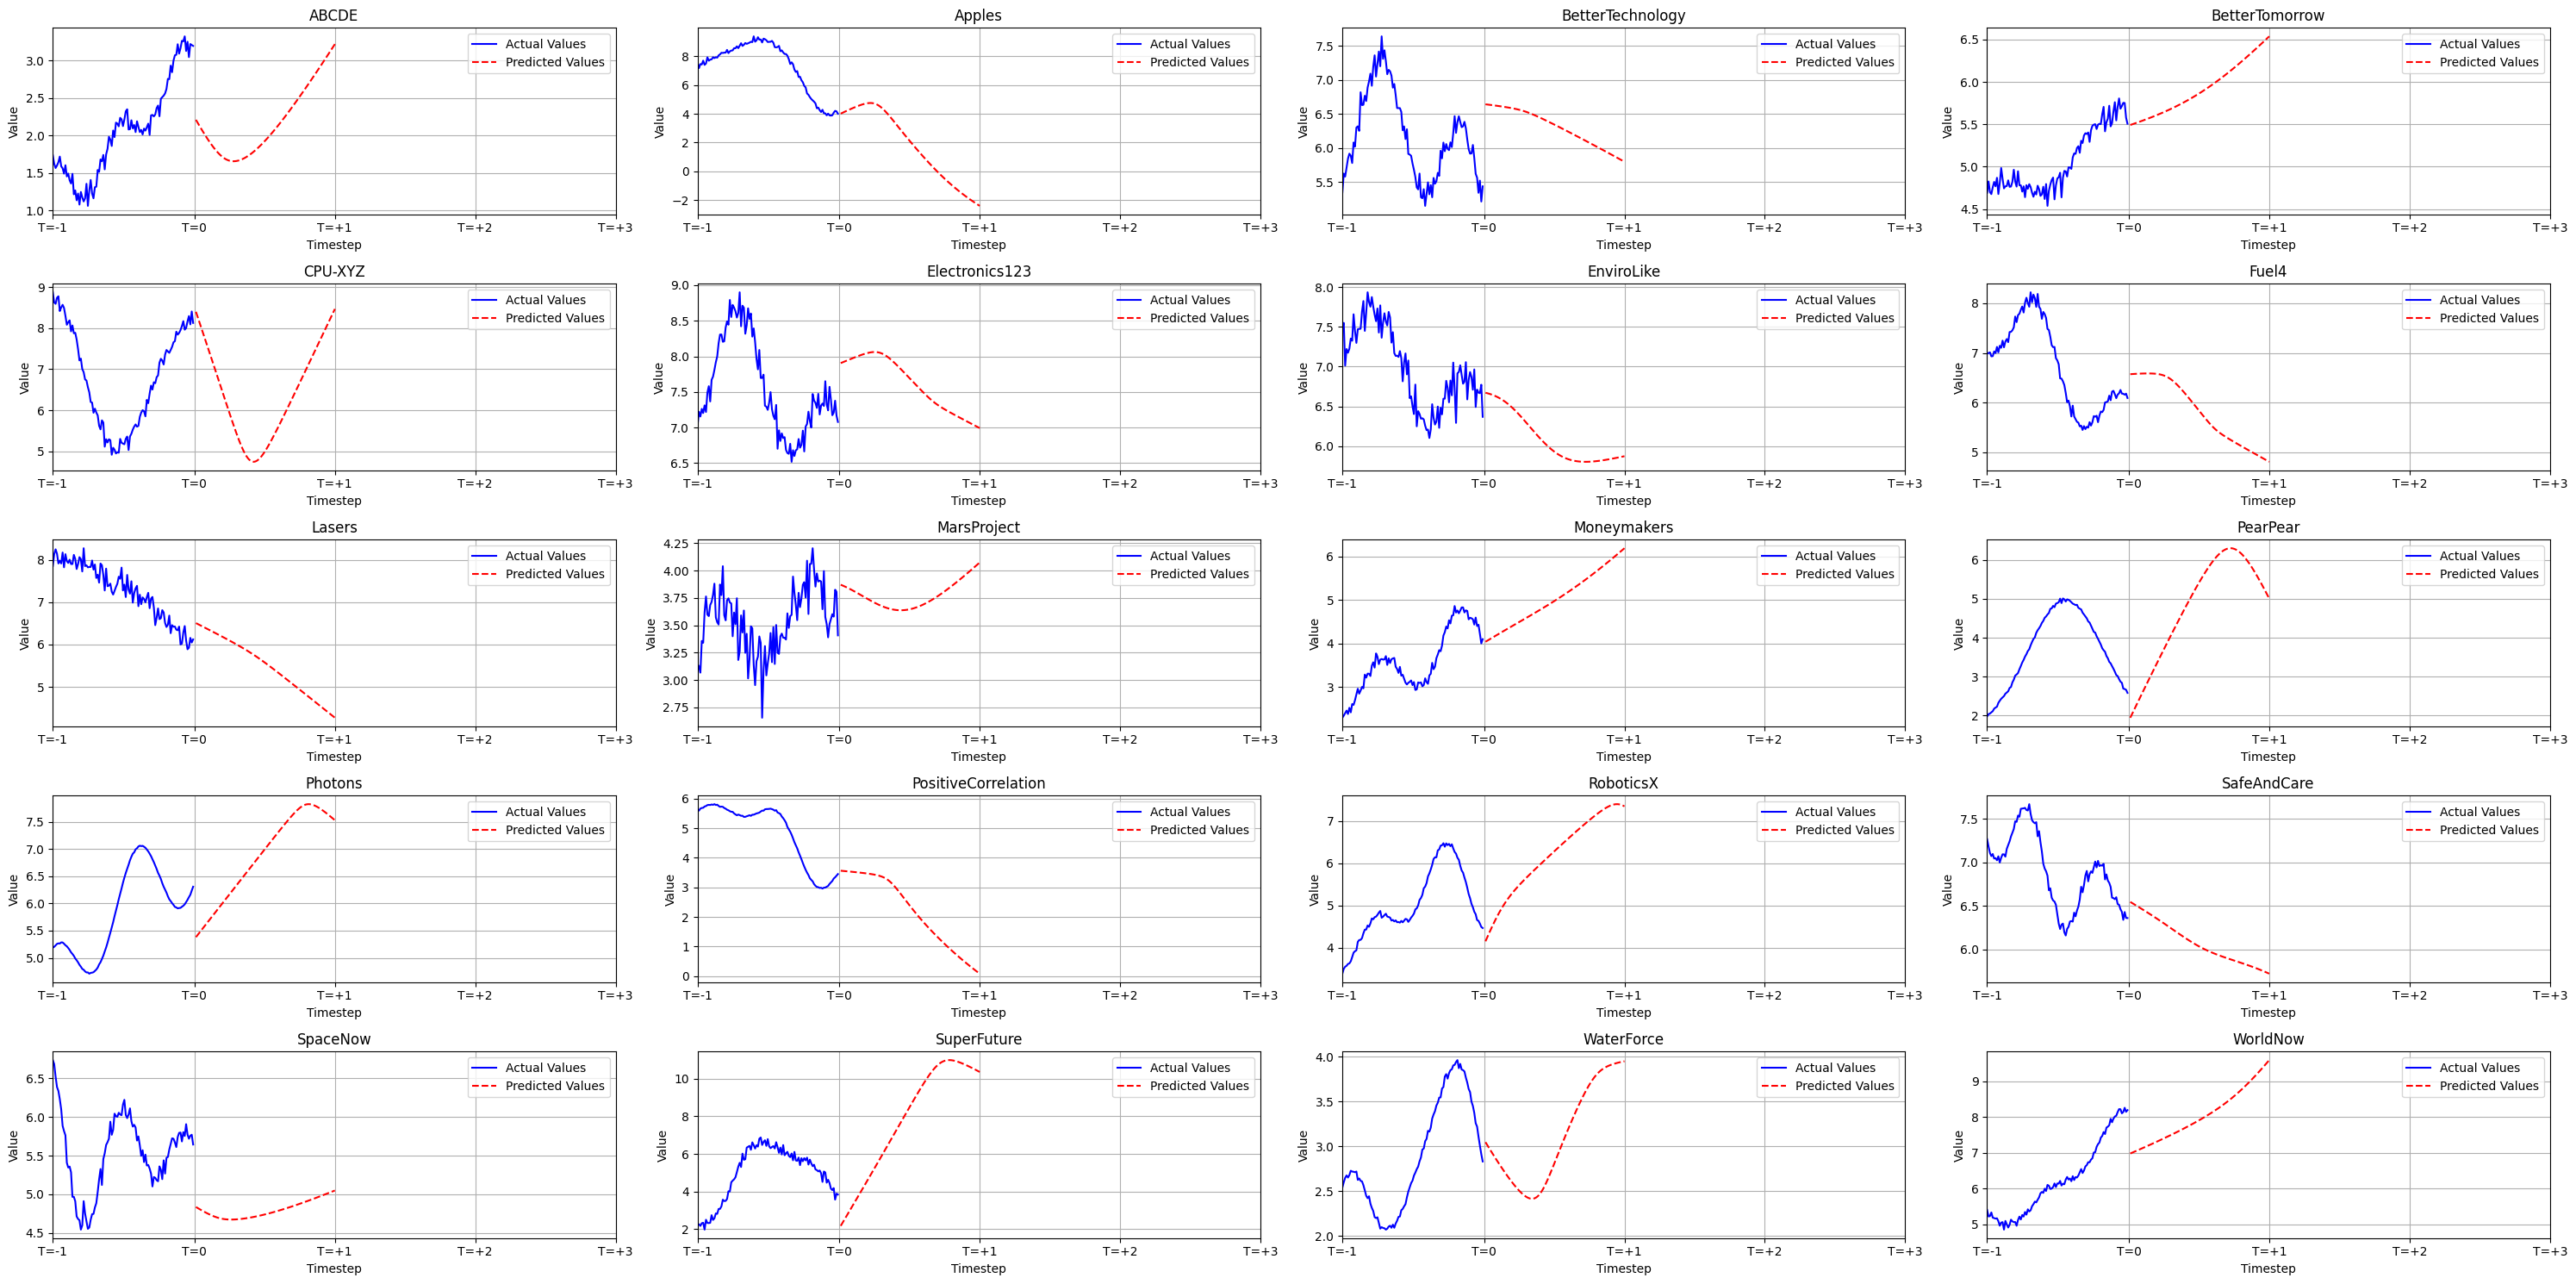

In [10]:
RMC = RegressionModelsCombined(data, window_size=50)
RMC.train_NODE()
NODE_predictions = RMC.predict_NODE()
RMC.plot_predictions(val_range=201, predictions=NODE_predictions, figsize=(30, 15))

## Single-Run WSM Run

In [11]:
risks = RMC.get_covariance_matrix()
solver = Solver(data, NODE_predictions, risks)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -4.2296e+00 -3.7838e+01  2e+02  3e+00  4e-16
 1: -1.1728e+00 -1.8745e+01  2e+01  1e-01  8e-16
 2: -8.5771e-01 -2.2232e+00  1e+00  3e-03  1e-15
 3: -1.5740e+00 -1.9262e+00  4e-01  1e-04  6e-16
 4: -1.6980e+00 -1.7018e+00  4e-03  1e-06  5e-16
 5: -1.6992e+00 -1.6993e+00  4e-05  1e-08  7e-16
 6: -1.6992e+00 -1.6992e+00  4e-07  1e-10  5e-16
Optimal solution found.


In [12]:
wsm_solutions_step_001 = solver.solve_wsm(step = 0.01)
wsm_solutions_step_025 = solver.solve_wsm(step = 0.25)
solutions = solver.solve_wsm()
wsm_solutions_step_01 = solutions.copy()

Running for w1=0.0, w2=1.0
     pcost       dcost       gap    pres   dres
 0: -1.0439e+00 -2.9231e+01  1e+02  2e+00  6e-16
 1: -3.0957e-01 -1.2077e+01  1e+01  5e-02  1e-15
 2: -2.9807e-01 -2.1199e+00  2e+00  6e-03  7e-16
 3: -6.3819e-01 -1.4511e+00  8e-01  6e-04  7e-16
 4: -8.2743e-01 -8.4684e-01  2e-02  1e-05  9e-16
 5: -8.3566e-01 -8.3586e-01  2e-04  1e-07  7e-16
 6: -8.3575e-01 -8.3575e-01  2e-06  1e-09  5e-16
 7: -8.3575e-01 -8.3575e-01  2e-08  1e-11  5e-16
Optimal solution found.
Running for w1=0.01, w2=0.99
     pcost       dcost       gap    pres   dres
 0: -9.8779e-01 -2.8966e+01  1e+02  2e+00  7e-16
 1: -3.0110e-01 -1.1895e+01  1e+01  5e-02  1e-15
 2: -2.9160e-01 -2.1042e+00  2e+00  6e-03  3e-15
 3: -6.2492e-01 -1.4190e+00  8e-01  6e-04  7e-16
 4: -8.0696e-01 -8.2769e-01  2e-02  1e-05  9e-16
 5: -8.1603e-01 -8.1624e-01  2e-04  1e-07  6e-16
 6: -8.1612e-01 -8.1613e-01  2e-06  1e-09  7e-16
 7: -8.1613e-01 -8.1613e-01  2e-08  1e-11  5e-16
Optimal solution found.
Running for w1=0

In [13]:
pretty_display(solutions)

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
0,1.699247,2.033381,1.000000e+00,1.911513e-10,6.505273e-10,5.473229e-10,6.645755e-10,5.020690e-10,4.275278e-10,2.609860e-10,...,8.631084e-10,4.568188e-10,6.656497e-10,5.758777e-10,9.061487e-10,4.219509e-10,7.947827e-10,5.042548e-10,6.605898e-10,1.0
1,1.699247,2.033381,1.000000e+00,4.956294e-10,1.689484e-09,1.843223e-09,1.544374e-09,1.536077e-09,4.962768e-10,8.186750e-10,...,3.183021e-09,1.570228e-09,2.484875e-09,5.667738e-09,2.550827e-09,1.476683e-09,3.034133e-09,1.776511e-09,2.223411e-09,1.0
2,1.550573,1.453484,9.102926e-01,2.160569e-10,6.362476e-10,6.780071e-10,6.233656e-10,5.841295e-10,1.276901e-09,3.321804e-10,...,9.496800e-10,5.916904e-10,8.199211e-10,8.970743e-02,9.880725e-10,5.573764e-10,9.006922e-10,6.451291e-10,7.701147e-10,1.0
3,1.235836,0.568690,7.203851e-01,2.544139e-09,3.312296e-09,1.011033e-08,4.320385e-09,4.489833e-09,1.115275e-08,3.473745e-09,...,1.005968e-08,8.601757e-09,1.140824e-08,2.796148e-01,8.323393e-09,6.975340e-09,8.822044e-09,7.610469e-09,6.682343e-09,1.0
4,1.078468,0.300923,6.254313e-01,7.430671e-09,4.634968e-09,4.364977e-08,7.693130e-09,1.097481e-08,4.302984e-08,1.220914e-08,...,1.242817e-08,4.333663e-08,2.749725e-08,3.745683e-01,1.206930e-08,3.067258e-08,1.004885e-08,2.586396e-08,1.269863e-08,1.0
5,0.984046,0.196145,5.684589e-01,1.216883e-08,3.031558e-09,1.403263e-07,5.110772e-09,1.065742e-08,7.026457e-08,2.351954e-08,...,6.500125e-09,2.102116e-07,3.093490e-08,4.315402e-01,6.400814e-09,9.683918e-08,3.921778e-09,4.649933e-08,9.368680e-09,1.0
6,0.902012,0.137807,5.218874e-01,1.495609e-09,1.810204e-10,3.399021e-08,3.002330e-10,6.963871e-10,1.000435e-08,3.796871e-09,...,4.378080e-10,1.919406e-02,2.800751e-09,4.589184e-01,4.406305e-10,4.743853e-08,4.069964e-10,5.715977e-09,5.875882e-10,1.0
7,0.762392,0.070930,4.539836e-01,3.081642e-10,2.617358e-10,7.317069e-10,4.430321e-10,4.904600e-10,7.394876e-09,8.877284e-10,...,5.403225e-10,7.397353e-02,1.072527e-09,4.336379e-01,6.103517e-10,3.840499e-02,6.827094e-10,7.063191e-10,6.095065e-10,1.0
8,0.630847,0.031506,3.838586e-01,1.971514e-09,1.378287e-09,1.562150e-08,3.027014e-09,3.272551e-09,1.634994e-02,4.214598e-09,...,2.564922e-09,7.178059e-02,7.121824e-09,4.009159e-01,3.199263e-09,1.270949e-01,3.481244e-09,4.418544e-09,3.547502e-09,1.0
9,0.486084,0.008303,1.414657e-01,6.794022e-10,5.366699e-10,2.138388e-08,1.148012e-09,8.884210e-10,2.936220e-01,7.996875e-10,...,1.083751e-09,1.594087e-01,3.858209e-09,3.652677e-01,1.512597e-09,4.023587e-02,1.380852e-09,3.598664e-09,1.431147e-09,1.0


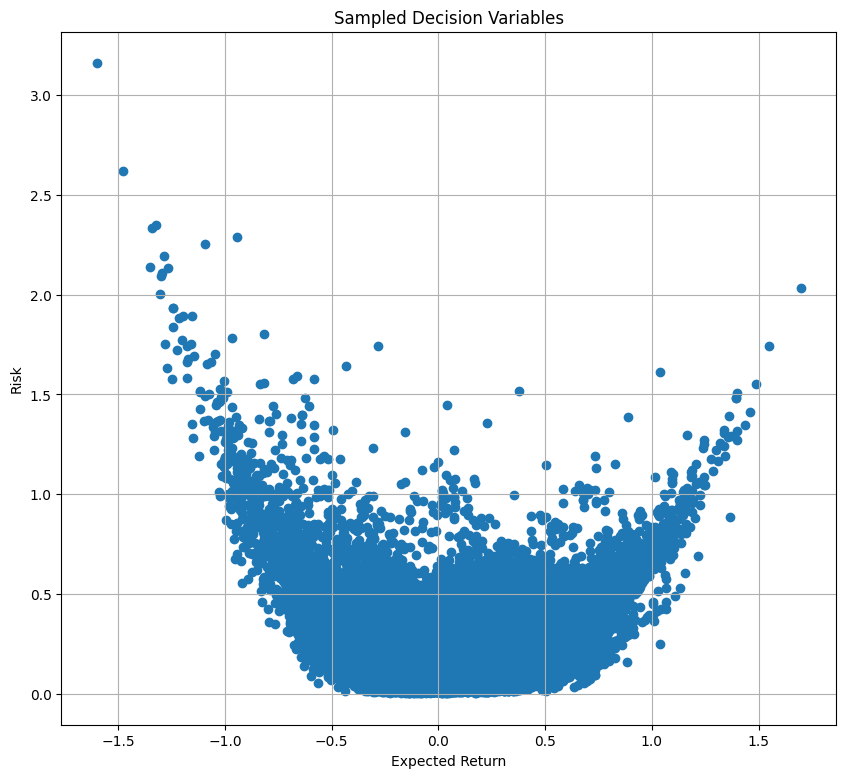

In [14]:
solver.plot_sampled_decision_variables(20, 0.2)

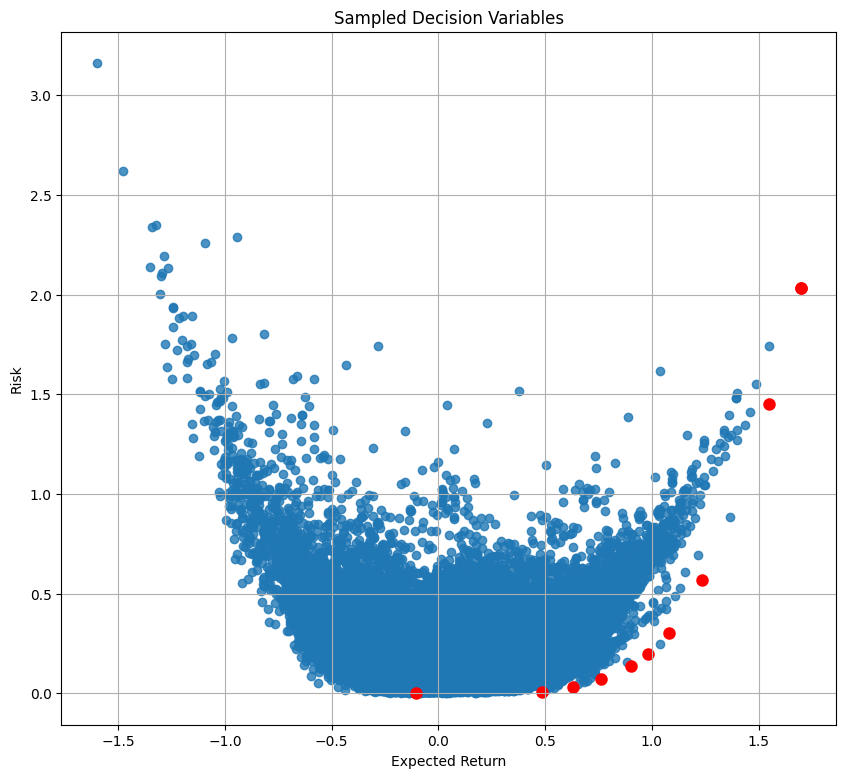

In [15]:
solver.plot_front(solutions, n=20, step=0.2)

### Single-Run ECM Algorithm

In [16]:
ecm_solutions_100 = solver.solve_ecm(num_thresholds=101)
ecm_solutions_4 = solver.solve_ecm(num_thresholds=4)
solutions = solver.solve_ecm()
ecm_solutions_10 = solutions.copy()

Running for threshold=-0.10573916345733039
     pcost       dcost       gap    pres   dres
 0:  1.6354e-03 -2.1936e+01  2e+01  7e-16  6e+00
 1:  1.3477e-03 -4.7287e-01  5e-01  1e-16  1e-01
 2:  7.1717e-04 -3.6923e-02  4e-02  2e-16  1e-02
 3:  3.1970e-04 -1.8622e-03  2e-03  1e-16  1e-04
 4:  2.1512e-04 -6.1865e-05  3e-04  2e-16  7e-06
 5:  1.8213e-04  1.5114e-04  3e-05  2e-16  1e-16
 6:  1.7678e-04  1.7551e-04  1e-06  2e-16  1e-16
 7:  1.7639e-04  1.7633e-04  7e-08  2e-16  1e-16
Optimal solution found.
Running for threshold=-0.08768930717090699
     pcost       dcost       gap    pres   dres
 0:  1.6883e-03 -2.1866e+01  2e+01  1e-15  6e+00
 1:  1.4123e-03 -4.9074e-01  5e-01  1e-16  1e-01
 2:  7.5490e-04 -3.7414e-02  4e-02  2e-16  1e-02
 3:  3.3342e-04 -2.6141e-03  3e-03  2e-16  4e-04
 4:  2.1821e-04 -4.4507e-05  3e-04  2e-16  8e-07
 5:  1.8523e-04  1.5493e-04  3e-05  2e-16  2e-16
 6:  1.8007e-04  1.7826e-04  2e-06  2e-16  1e-16
 7:  1.7944e-04  1.7938e-04  6e-08  1e-16  1e-16
Optimal so

In [17]:
pretty_display(solutions)

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
0,-0.104701,0.000176,4.875266e-07,3.546266e-06,1.044542e-01,2.677846e-02,1.298515e-01,2.003516e-02,8.593769e-07,1.826334e-01,...,4.151252e-02,8.312275e-02,7.126414e-03,4.386650e-02,2.258050e-03,5.653471e-06,7.995432e-02,1.474001e-01,3.840301e-02,1.0
1,0.074760,0.000366,1.214567e-07,1.347526e-07,3.970772e-02,4.938229e-02,1.959977e-01,3.639772e-02,1.143577e-01,5.405661e-02,...,4.743309e-05,1.466606e-01,1.359463e-02,1.311416e-01,6.883199e-07,3.749650e-03,6.046505e-03,9.782117e-02,5.794585e-02,1.0
2,0.255258,0.001097,8.842246e-07,1.817002e-07,3.433312e-07,4.278252e-02,1.043208e-01,1.990718e-02,2.900978e-01,1.111694e-02,...,5.110837e-07,1.946718e-01,6.962149e-05,2.447378e-01,5.779847e-07,1.218330e-02,6.654895e-07,9.853327e-03,6.265826e-02,1.0
3,0.435757,0.004417,5.719563e-02,3.961797e-09,4.577263e-09,5.623330e-08,1.263046e-08,3.334206e-08,3.900184e-01,5.883757e-08,...,6.974072e-09,1.898724e-01,2.174503e-08,3.528741e-01,7.662262e-09,1.003913e-02,1.065692e-08,1.632047e-08,1.588269e-08,1.0
4,0.616255,0.028358,3.594383e-01,3.064897e-10,1.854644e-10,2.388615e-09,4.097171e-10,4.089200e-10,4.427903e-02,1.747554e-09,...,3.986273e-10,8.060661e-02,1.145757e-09,3.973227e-01,4.677200e-10,1.183534e-01,4.911376e-10,6.325555e-10,5.360059e-10,1.0
5,0.796754,0.084729,4.695795e-01,5.679366e-09,3.310774e-09,1.683435e-08,5.918444e-09,7.523187e-09,8.494866e-08,1.468812e-08,...,6.900180e-09,7.602941e-02,1.498778e-08,4.421911e-01,8.144319e-09,1.219975e-02,8.655411e-09,1.383075e-08,8.006760e-09,1.0
6,0.977252,0.190221,5.643593e-01,6.071166e-10,1.379658e-10,7.936792e-09,3.508020e-10,6.979700e-10,5.860787e-09,1.260620e-09,...,4.057229e-10,1.122607e-08,2.051825e-09,4.356407e-01,4.714363e-10,5.131722e-09,4.463968e-10,2.564232e-09,6.881065e-10,1.0
7,1.157751,0.421273,6.732694e-01,6.569015e-10,8.414944e-10,2.845090e-09,1.088697e-09,1.207570e-09,4.679253e-09,9.833349e-10,...,2.077822e-09,2.105700e-09,2.944393e-09,3.267305e-01,2.087931e-09,1.577810e-09,2.065800e-09,2.079931e-09,1.836593e-09,1.0
8,1.338249,0.805484,7.821796e-01,4.099762e-09,7.484066e-09,1.242174e-08,7.716652e-09,7.526893e-09,1.497605e-08,5.925126e-09,...,1.272223e-08,7.958375e-09,1.660203e-08,2.178202e-01,1.341018e-08,6.283944e-09,1.307620e-08,1.088232e-08,1.234878e-08,1.0
9,1.518748,1.342853,8.910898e-01,-2.798204e-11,8.539659e-11,8.949178e-11,1.804959e-11,-7.971508e-12,-6.922028e-11,2.227385e-11,...,6.456967e-10,-6.487007e-11,3.330605e-10,1.089102e-01,3.644384e-10,-1.136686e-10,5.943251e-10,6.772092e-11,2.204615e-10,1.0


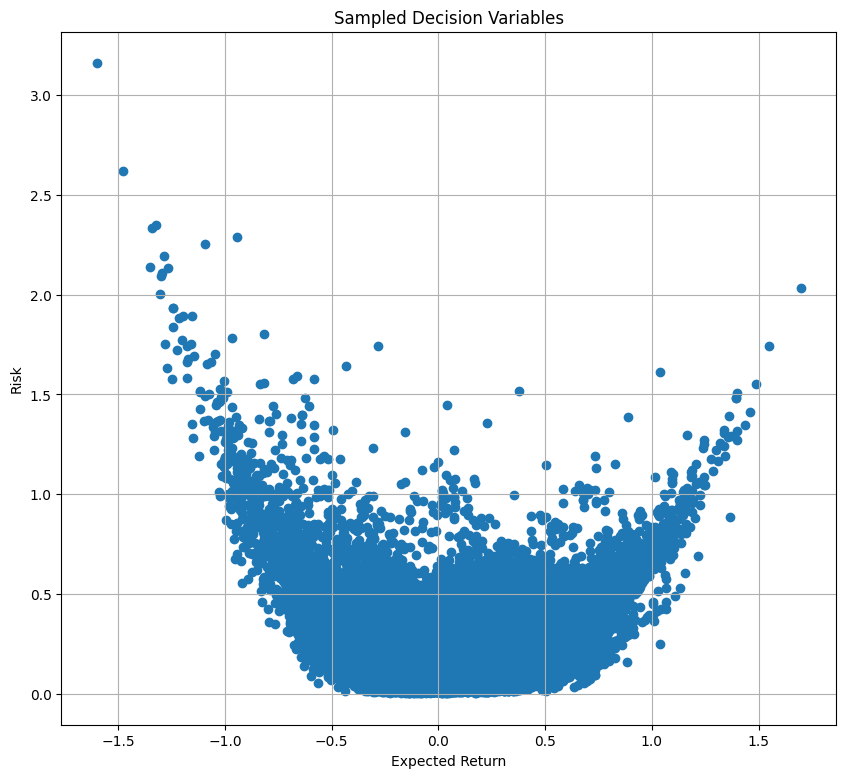

In [18]:
solver.plot_sampled_decision_variables(20, 0.2)

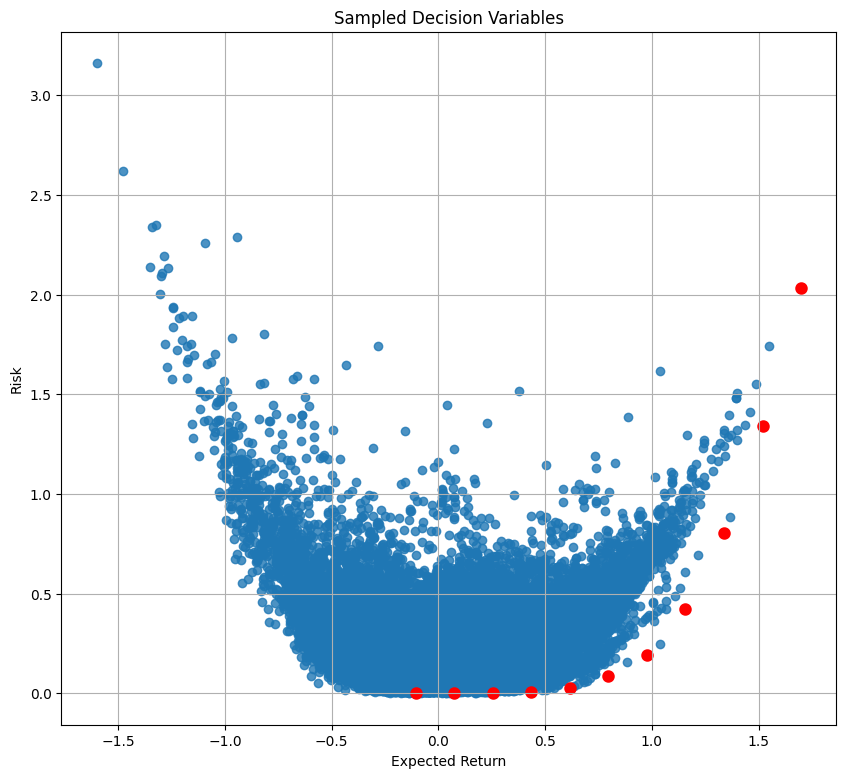

In [19]:
solver.plot_front(solutions, n=20, step=0.2)

## Comparison

### WSM VS ECM Pareto Front Spread

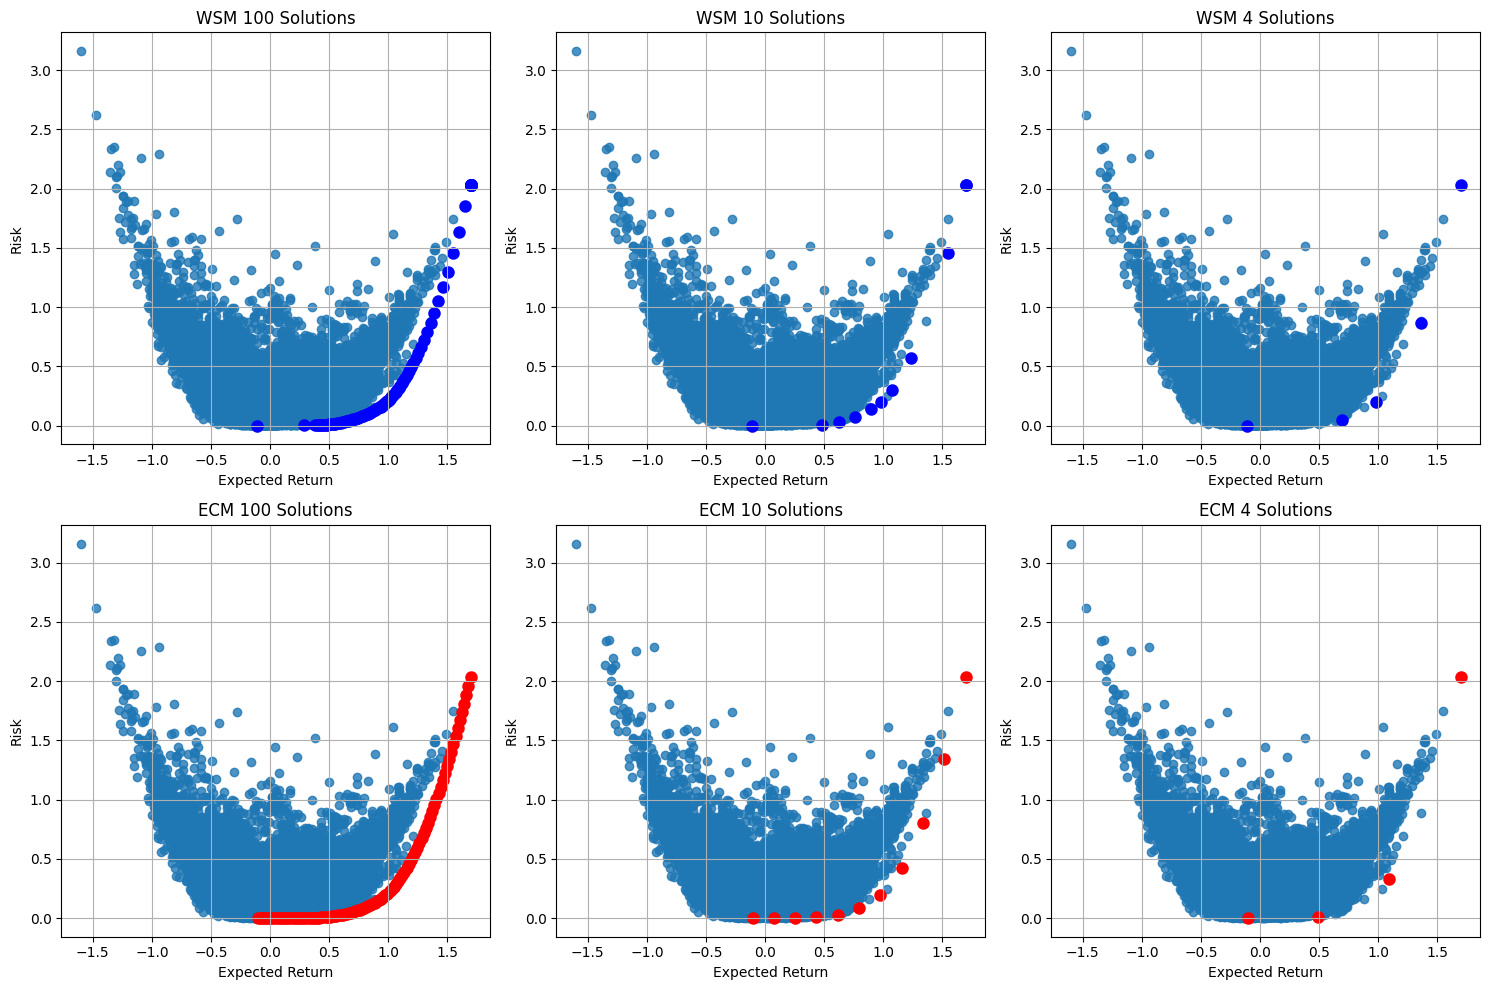

In [20]:
solutions_list = [wsm_solutions_step_001, wsm_solutions_step_01, wsm_solutions_step_025, ecm_solutions_100, ecm_solutions_10, ecm_solutions_4]
titles = ["WSM 100 Solutions", "WSM 10 Solutions", "WSM 4 Solutions", "ECM 100 Solutions", "ECM 10 Solutions", "ECM 4 Solutions"]
solver.plot_multiple_fronts(solutions_list, titles, n=20, step=0.2)

### Single Threshold/Step Tests

In [21]:
thresholds = [200]
steps = [1/200]

ER = ExperimentRunner(solver=solver)
ER.run_ECM(thresholds)
ER.run_WSM(steps)

Running for threshold=-0.10573916345733039
     pcost       dcost       gap    pres   dres
 0:  1.6354e-03 -2.1936e+01  2e+01  7e-16  6e+00
 1:  1.3477e-03 -4.7287e-01  5e-01  1e-16  1e-01
 2:  7.1717e-04 -3.6923e-02  4e-02  2e-16  1e-02
 3:  3.1970e-04 -1.8622e-03  2e-03  1e-16  1e-04
 4:  2.1512e-04 -6.1865e-05  3e-04  2e-16  7e-06
 5:  1.8213e-04  1.5114e-04  3e-05  2e-16  1e-16
 6:  1.7678e-04  1.7551e-04  1e-06  2e-16  1e-16
 7:  1.7639e-04  1.7633e-04  7e-08  2e-16  1e-16
Optimal solution found.
Running for threshold=-0.09666888391641411
     pcost       dcost       gap    pres   dres
 0:  1.6591e-03 -2.1901e+01  2e+01  2e-15  6e+00
 1:  1.3780e-03 -4.8189e-01  5e-01  2e-16  1e-01
 2:  7.3549e-04 -3.7181e-02  4e-02  2e-16  1e-02
 3:  3.2640e-04 -2.2515e-03  3e-03  2e-16  3e-04
 4:  2.1646e-04 -6.3492e-05  3e-04  2e-16  7e-06
 5:  1.8324e-04  1.5162e-04  3e-05  2e-16  1e-16
 6:  1.7764e-04  1.7634e-04  1e-06  2e-16  2e-16
 7:  1.7711e-04  1.7708e-04  4e-08  1e-16  2e-16
Optimal so

In [22]:
top_ecm, top_wsm = ER.summarize()
top_wsm

,Solution Signature,Frequency,Method
0,"(0.9999999892447419, 1.9115133548974165e-10, 6...",1,WSM
1,"(0.9999999885146329, 2.0467844657378185e-10, 6...",1,WSM
2,"(0.9999999877559663, 2.1866889942493702e-10, 7...",1,WSM
3,"(0.9999999869689072, 2.329855880107684e-10, 7....",1,WSM
4,"(0.9999999861518025, 2.4752963415186664e-10, 8...",1,WSM
5,"(0.999999985304041, 2.621898737161864e-10, 8.4...",1,WSM
6,"(0.999999984423136, 2.7689385397570666e-10, 8....",1,WSM
7,"(0.9999999835056456, 2.9158902789097745e-10, 9...",1,WSM
8,"(0.9999999825460146, 3.062597409887121e-10, 9....",1,WSM
9,"(0.9999999815297033, 3.210417350278691e-10, 1....",1,WSM


In [23]:
top_ecm

,Solution Signature,Frequency,Method
0,"(4.875266348295227e-07, 3.546266459674232e-06,...",1,ECM
1,"(1.3424443760689795e-06, 1.3259320716423018e-0...",1,ECM
2,"(9.60219248957545e-06, 9.492281820115111e-07, ...",1,ECM
3,"(1.2631926002546167e-05, 4.7573030564347656e-0...",1,ECM
4,"(3.851726402232792e-06, 2.7335363075380827e-07...",1,ECM
5,"(2.0908539602280416e-06, 2.642172161505229e-07...",1,ECM
6,"(1.299455016040616e-06, 1.5888747539346712e-07...",1,ECM
7,"(9.653693006834714e-07, 1.08148117939413e-07, ...",1,ECM
8,"(7.3189927522308e-07, 7.849206666295073e-08, 0...",1,ECM
9,"(1.1239413020402348e-06, 1.3867920058801552e-0...",1,ECM


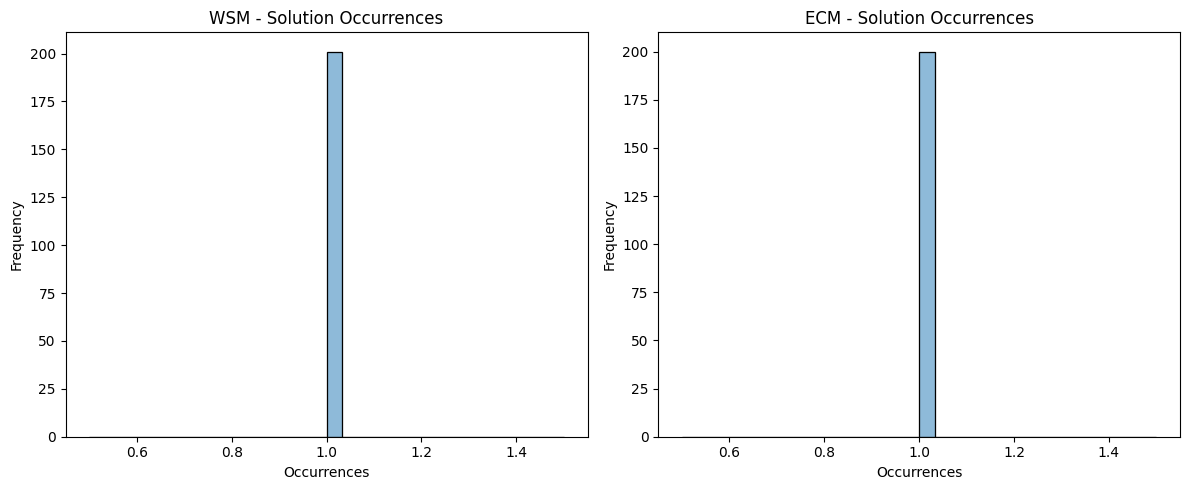

In [24]:
ER.plot_results()

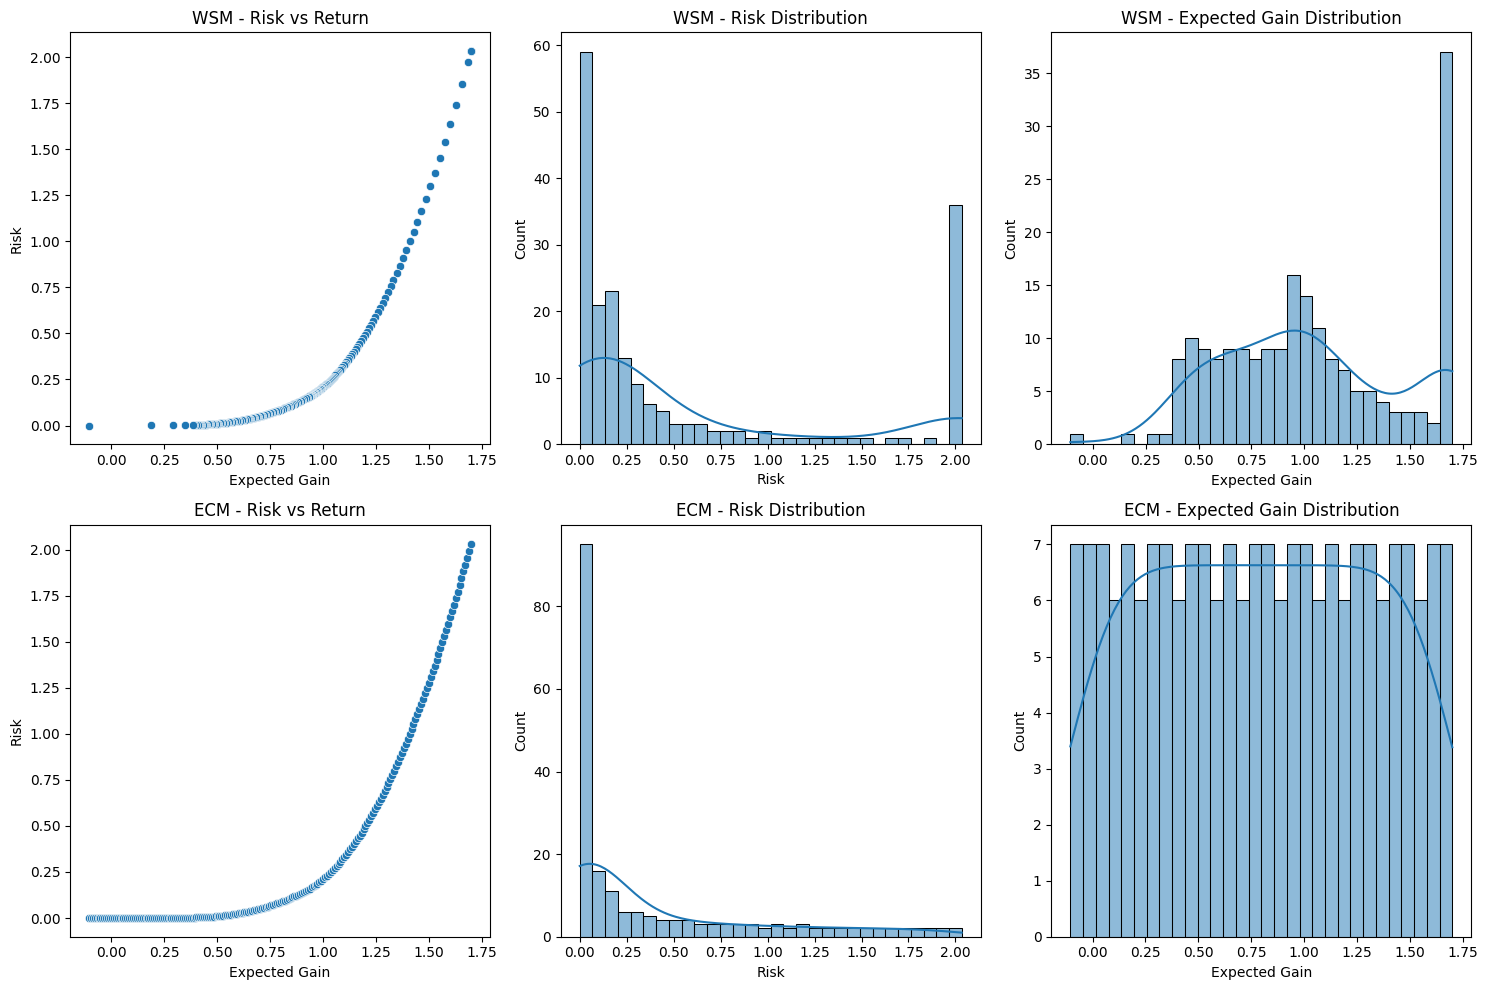

In [25]:
ER.plot_risk_return_distribution()

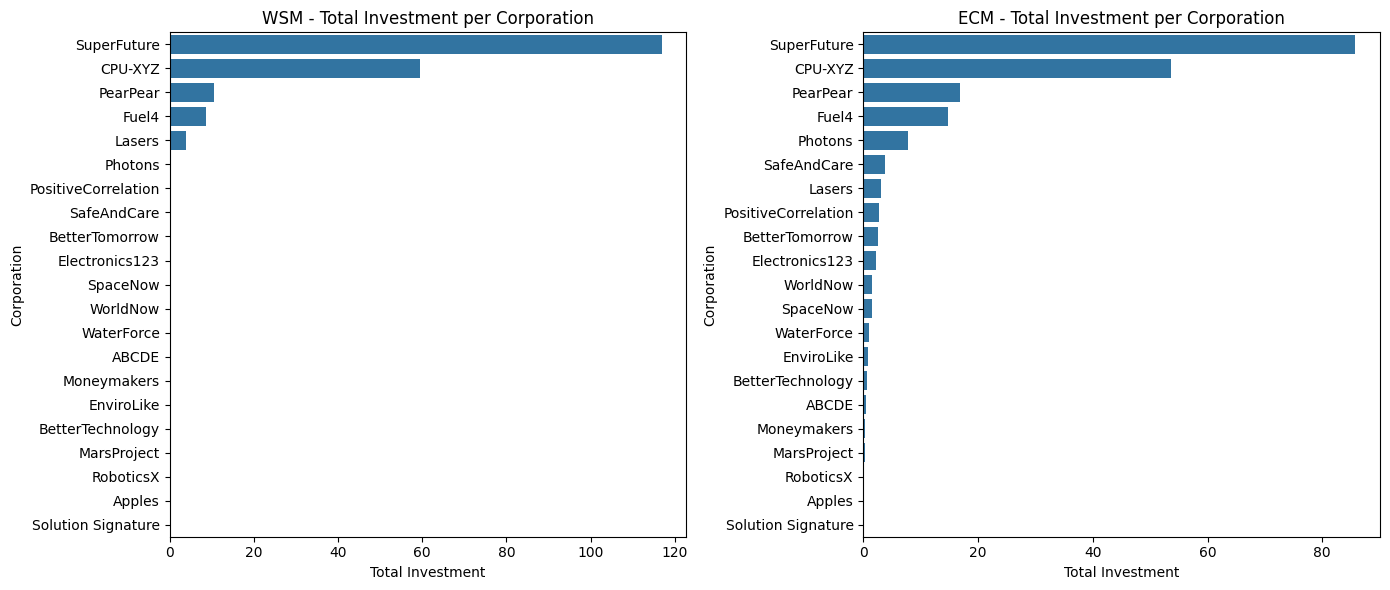

In [26]:
ER.plot_top_corporations()

### 2 to 32 Thresholds/Steps Experiments

In [27]:
thresholds = [2, 4, 8, 12, 16, 20, 32]
steps = [1/2, 1/4, 1/8, 1/16, 1/20, 1/32]

ER = ExperimentRunner(solver=solver)
ER.run_ECM(thresholds)
ER.run_WSM(steps)

Running for threshold=-0.10573916345733039
     pcost       dcost       gap    pres   dres
 0:  1.6354e-03 -2.1936e+01  2e+01  7e-16  6e+00
 1:  1.3477e-03 -4.7287e-01  5e-01  1e-16  1e-01
 2:  7.1717e-04 -3.6923e-02  4e-02  2e-16  1e-02
 3:  3.1970e-04 -1.8622e-03  2e-03  1e-16  1e-04
 4:  2.1512e-04 -6.1865e-05  3e-04  2e-16  7e-06
 5:  1.8213e-04  1.5114e-04  3e-05  2e-16  1e-16
 6:  1.7678e-04  1.7551e-04  1e-06  2e-16  1e-16
 7:  1.7639e-04  1.7633e-04  7e-08  2e-16  1e-16
Optimal solution found.
Running for threshold=1.6992464651850094
     pcost       dcost       gap    pres   dres
 0:  1.1926e-01 -2.3629e+01  1e+02  2e+00  6e+00
 1:  5.8858e-01 -1.2435e+01  3e+01  3e-01  1e+00
 2:  1.2400e+00 -2.4822e+00  8e+00  8e-02  2e-01
 3:  1.7977e+00  1.4486e+00  9e-01  1e-02  3e-02
 4:  2.0305e+00  2.0263e+00  1e-02  1e-04  3e-04
 5:  2.0334e+00  2.0333e+00  1e-04  1e-06  3e-06
 6:  2.0334e+00  2.0334e+00  2e-06  2e-08  6e-08
 7:  2.0334e+00  2.0334e+00  7e-08  2e-10  5e-10
Optimal solu

In [28]:
top_ecm, top_wsm = ER.summarize()
top_wsm

,Solution Signature,Frequency,Method
0,"(0.9999999892447419, 1.9115133548974165e-10, 6...",6,WSM
1,"(0.5684588656424605, 1.2168831289673845e-08, 3...",6,WSM
2,"(2.19300609183342e-07, 1.638823009642466e-07, ...",6,WSM
3,"(0.7963481323202932, 3.887017939563731e-10, 1....",5,WSM
4,"(0.42277529330171, 3.74400465386269e-10, 5.470...",5,WSM
5,"(0.9999999283343589, 6.097144826959461e-10, 2....",3,WSM
6,"(0.644421973931184, 8.184052528605096e-09, 9.2...",3,WSM
7,"(0.5040479645404354, 2.682063748218091e-09, 1....",3,WSM
8,"(0.19687467121867264, 6.775904126912452e-10, 3...",3,WSM
9,"(0.9999999774335552, 3.731750924462426e-10, 1....",2,WSM


In [29]:
top_ecm

,Solution Signature,Frequency,Method
0,"(4.875266348295227e-07, 3.546266459674232e-06,...",7,ECM
1,"(0.9999999231144038, 1.9680332518196933e-10, 2...",7,ECM
2,"(0.15794034787516997, 6.895294924888151e-10, 2...",2,ECM
3,"(0.6369660412900481, 2.146064880498298e-09, 1....",2,ECM
4,"(3.15231180182939e-08, 1.0597236857635561e-08,...",1,ECM
5,"(0.01822204174503611, 1.1765760290527115e-09, ...",1,ECM
6,"(0.41106150627410526, 8.346380566648393e-10, 4...",1,ECM
7,"(0.5338321441106497, 5.745328597607056e-10, 7....",1,ECM
8,"(0.6888280274934734, 4.231191278836121e-10, 6....",1,ECM
9,"(0.8444139755099143, 1.2250959189572638e-12, 8...",1,ECM


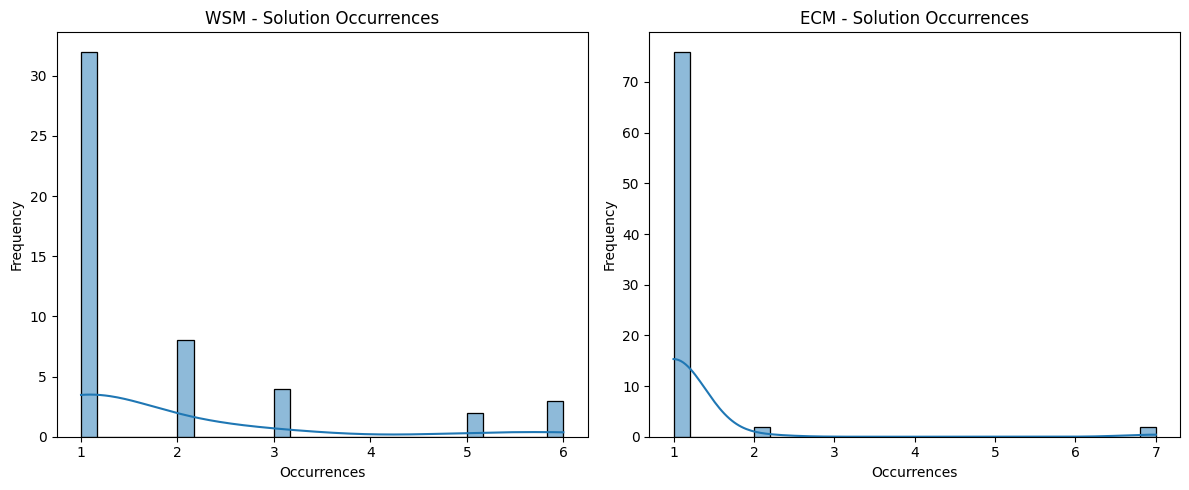

In [30]:
ER.plot_results()

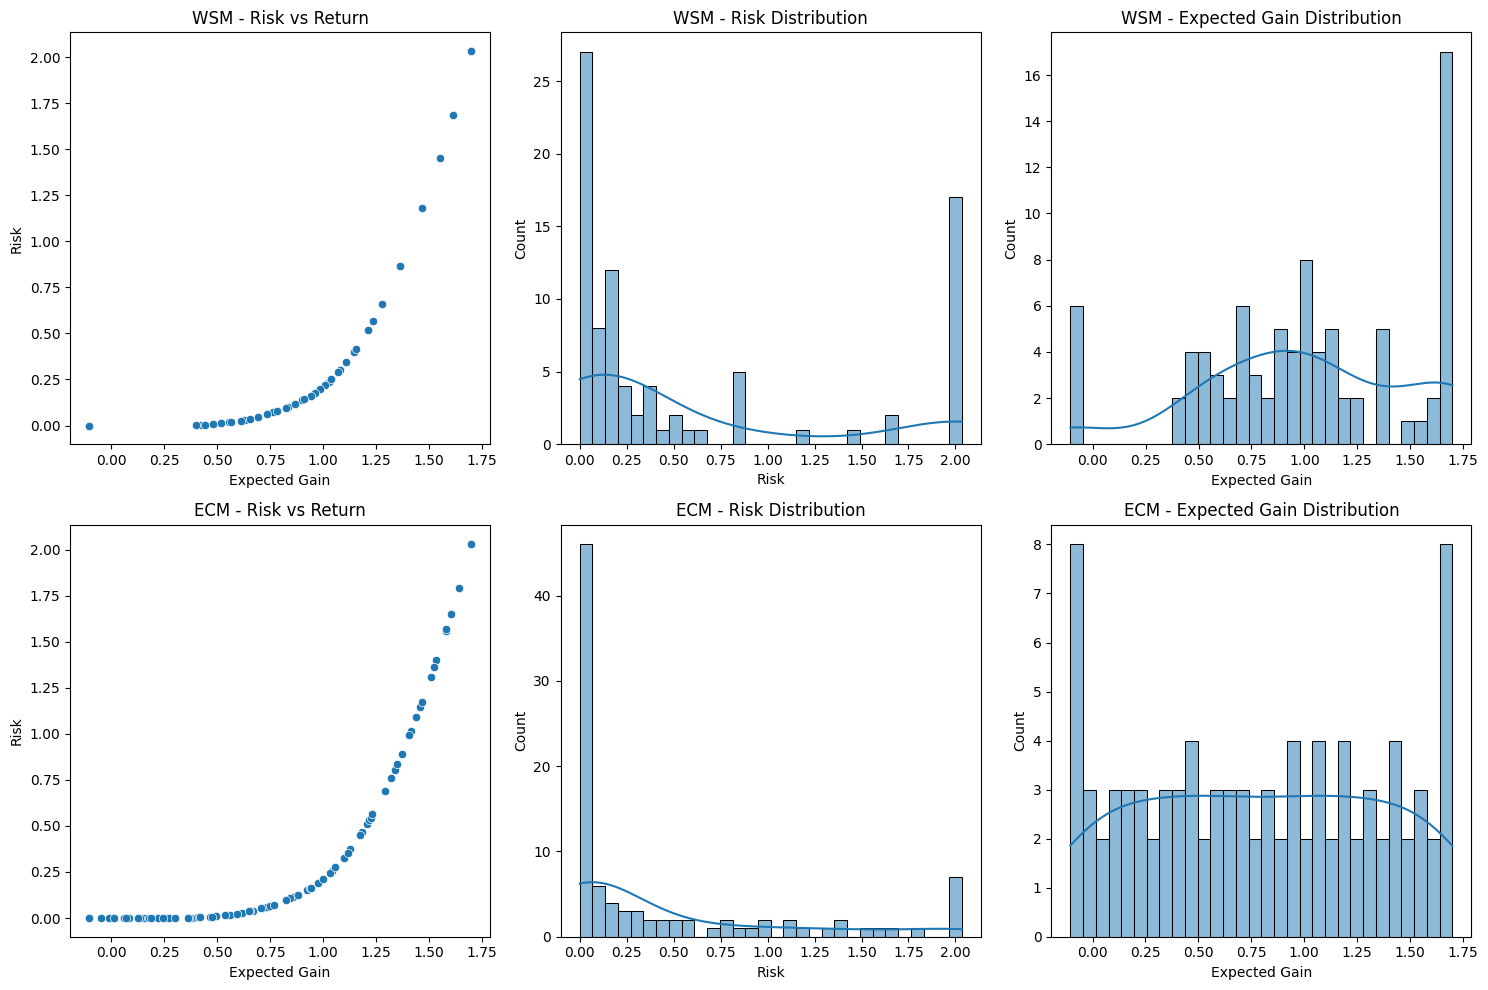

In [31]:
ER.plot_risk_return_distribution()

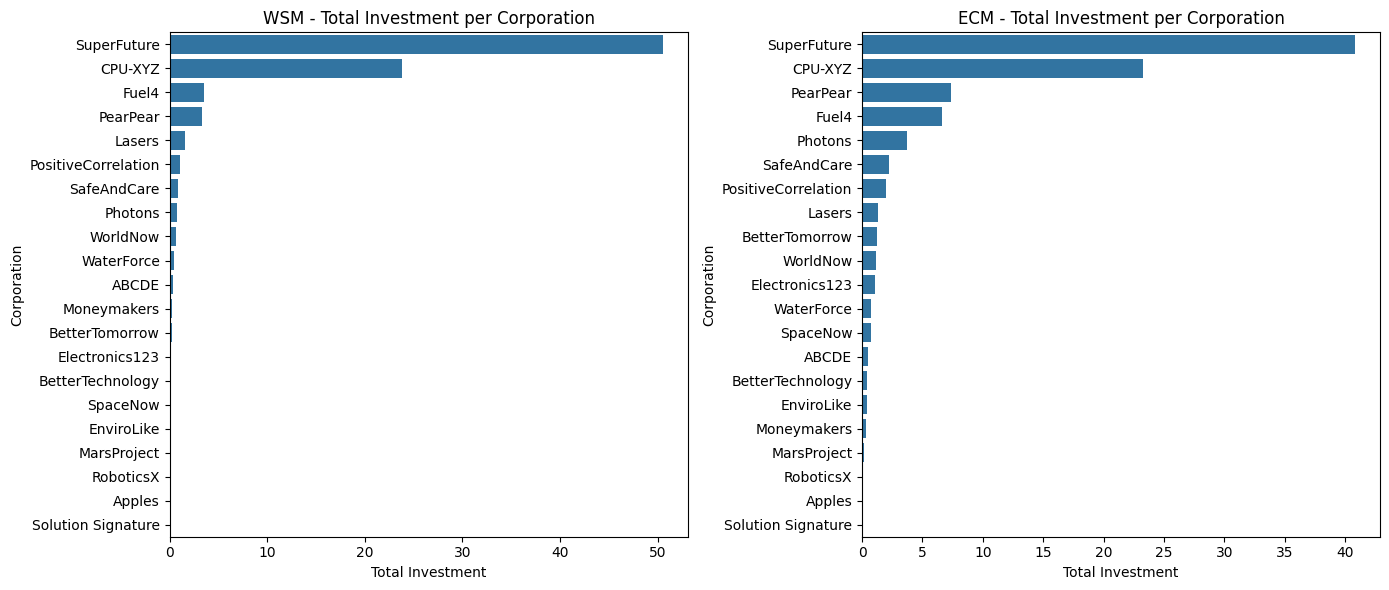

In [32]:
ER.plot_top_corporations()

### 2 to 256 Thresholds/Steps Experiments

In [33]:
thresholds = [2, 4, 8, 12, 16, 20, 32, 64, 128, 256]
steps = [1/2, 1/4, 1/8, 1/16, 1/20, 1/32, 1/64, 1/128, 1/256]

ER = ExperimentRunner(solver=solver)
ER.run_ECM(thresholds)
ER.run_WSM(steps)

Running for threshold=-0.10573916345733039
     pcost       dcost       gap    pres   dres
 0:  1.6354e-03 -2.1936e+01  2e+01  7e-16  6e+00
 1:  1.3477e-03 -4.7287e-01  5e-01  1e-16  1e-01
 2:  7.1717e-04 -3.6923e-02  4e-02  2e-16  1e-02
 3:  3.1970e-04 -1.8622e-03  2e-03  1e-16  1e-04
 4:  2.1512e-04 -6.1865e-05  3e-04  2e-16  7e-06
 5:  1.8213e-04  1.5114e-04  3e-05  2e-16  1e-16
 6:  1.7678e-04  1.7551e-04  1e-06  2e-16  1e-16
 7:  1.7639e-04  1.7633e-04  7e-08  2e-16  1e-16
Optimal solution found.
Running for threshold=1.6992464651850094
     pcost       dcost       gap    pres   dres
 0:  1.1926e-01 -2.3629e+01  1e+02  2e+00  6e+00
 1:  5.8858e-01 -1.2435e+01  3e+01  3e-01  1e+00
 2:  1.2400e+00 -2.4822e+00  8e+00  8e-02  2e-01
 3:  1.7977e+00  1.4486e+00  9e-01  1e-02  3e-02
 4:  2.0305e+00  2.0263e+00  1e-02  1e-04  3e-04
 5:  2.0334e+00  2.0333e+00  1e-04  1e-06  3e-06
 6:  2.0334e+00  2.0334e+00  2e-06  2e-08  6e-08
 7:  2.0334e+00  2.0334e+00  7e-08  2e-10  5e-10
Optimal solu

In [34]:
top_ecm, top_wsm = ER.summarize()
top_wsm

,Solution Signature,Frequency,Method
0,"(0.5684588656424605, 1.2168831289673845e-08, 3...",9,WSM
1,"(2.19300609183342e-07, 1.638823009642466e-07, ...",9,WSM
2,"(0.9999999892447419, 1.9115133548974165e-10, 6...",9,WSM
3,"(0.7963481323202932, 3.887017939563731e-10, 1....",8,WSM
4,"(0.42277529330171, 3.74400465386269e-10, 5.470...",8,WSM
5,"(0.644421973931184, 8.184052528605096e-09, 9.2...",6,WSM
6,"(0.9999999283343589, 6.097144826959461e-10, 2....",6,WSM
7,"(0.5040479645404354, 2.682063748218091e-09, 1....",6,WSM
8,"(0.19687467121867264, 6.775904126912452e-10, 3...",6,WSM
9,"(0.4624949267231906, 3.567835982840834e-10, 1....",5,WSM


In [35]:
top_ecm

,Solution Signature,Frequency,Method
0,"(0.9999999231144038, 1.9680332518196933e-10, 2...",10,ECM
1,"(4.875266348295227e-07, 3.546266459674232e-06,...",10,ECM
2,"(0.15794034787516997, 6.895294924888151e-10, 2...",4,ECM
3,"(0.6369660412900481, 2.146064880498298e-09, 1....",4,ECM
4,"(0.4422711718464903, 2.092627337675773e-09, 1....",2,ECM
5,"(0.4991308374803352, 1.300916066030075e-09, 6....",2,ECM
6,"(0.5643592727578908, 6.071165685964922e-10, 1....",2,ECM
7,"(0.7095728209819493, 2.48429577025094e-10, 4.1...",2,ECM
8,"(0.7821795906517102, 4.099761655191509e-09, 7....",2,ECM
9,"(0.8547863718403251, -1.8356752420493268e-11, ...",2,ECM


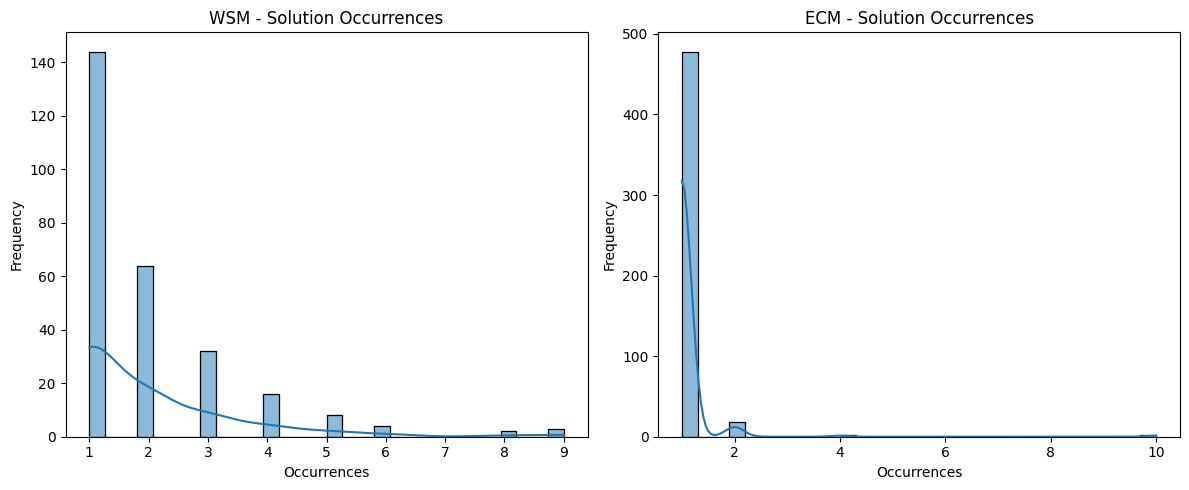

In [36]:
ER.plot_results()

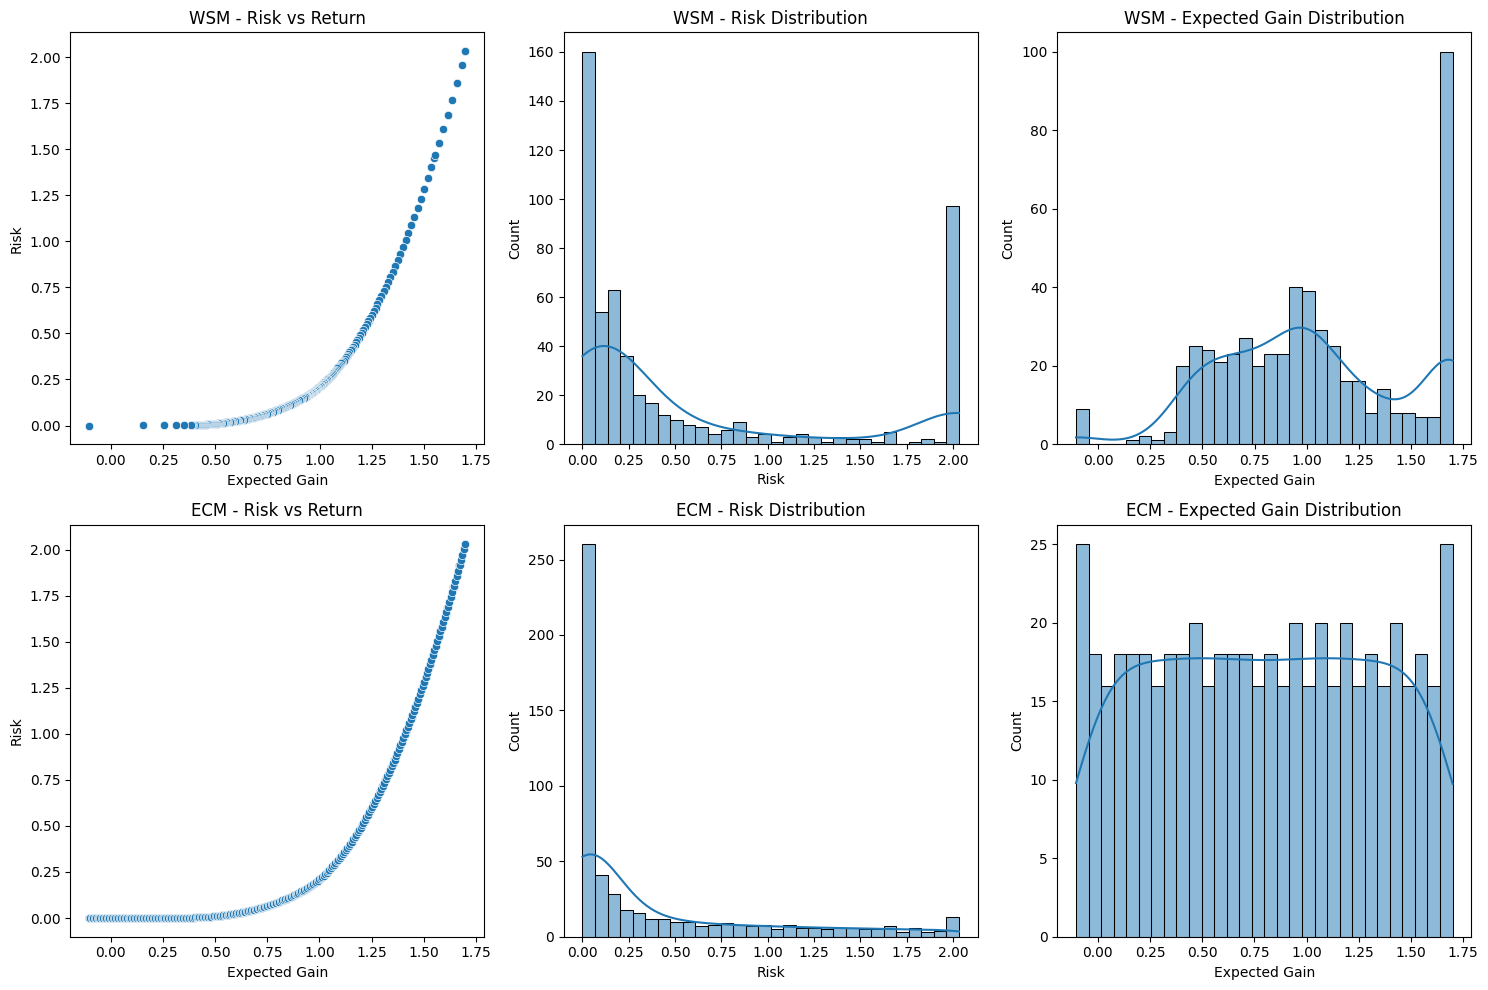

In [37]:
ER.plot_risk_return_distribution()

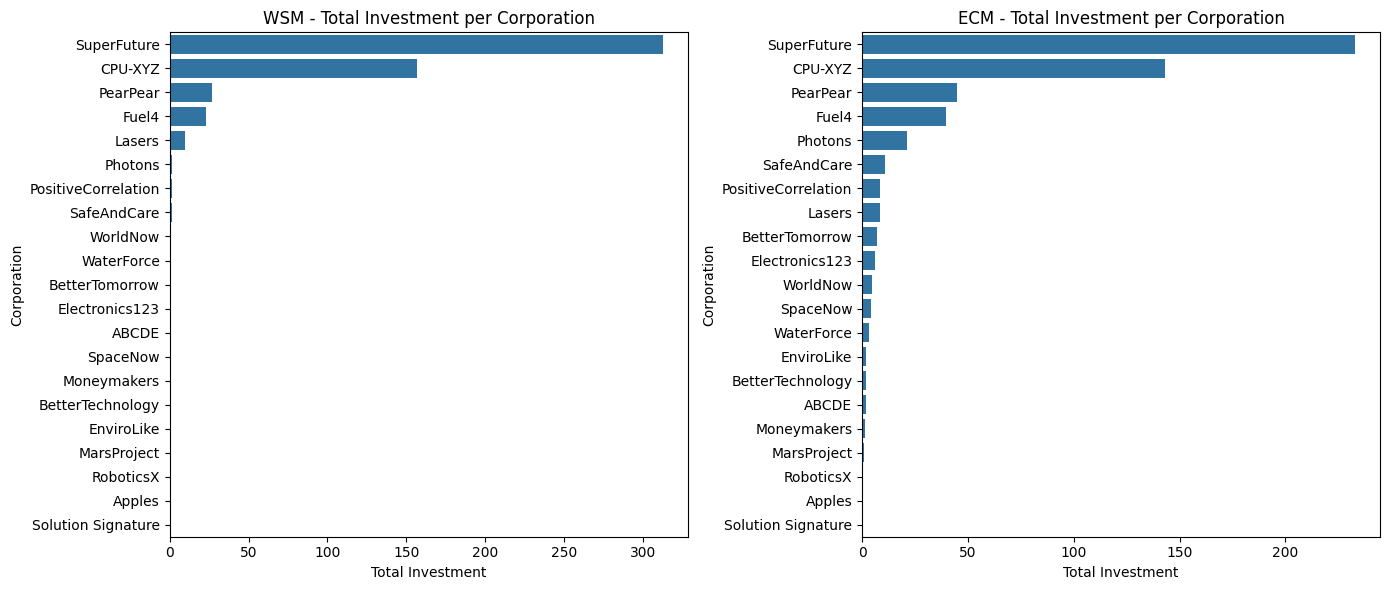

In [38]:
ER.plot_top_corporations()

In [39]:
ECM_results = ER.results_ECM
ECM_results_filtered = ECM_results[ECM_results["Expected Gain"] > 0]
ECM_results_sorted = ECM_results_filtered.sort_values(by="Risk", ascending=True)
ECM_results_sorted.drop(columns=["Solution Signature"], inplace=True)

ECM_results_sorted = ECM_results_sorted.head(40)
ECM_results_sorted

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
301,0.000437,0.000250,1.120756e-06,1.726839e-07,0.063320,0.042615,0.181415,0.028246,0.060783,0.100409,...,1.230432e-02,0.127690,0.010979,0.091607,1.198967e-06,0.000963,4.190585e-02,0.120803,0.047946,1.0
302,0.007515,0.000259,1.156813e-06,2.411698e-07,0.061351,0.043345,0.182873,0.028772,0.065871,0.095805,...,1.038822e-02,0.129774,0.011271,0.095293,1.394163e-06,0.001174,3.894503e-02,0.118849,0.048916,1.0
166,0.007961,0.000259,2.556452e-08,7.999662e-09,0.060897,0.043474,0.182721,0.028908,0.066367,0.095832,...,1.020078e-02,0.129746,0.011295,0.095641,3.481090e-08,0.000441,3.875149e-02,0.119027,0.049229,1.0
98,0.008863,0.000261,2.524780e-08,7.941047e-09,0.060647,0.043568,0.182907,0.028974,0.067016,0.095245,...,9.952938e-03,0.130012,0.011333,0.096111,3.446767e-08,0.000467,3.837614e-02,0.118780,0.049353,1.0
64,0.010712,0.000263,8.277134e-08,1.413656e-08,0.060178,0.043750,0.183319,0.029095,0.068323,0.094001,...,9.448474e-03,0.130581,0.011409,0.097058,8.485145e-08,0.000612,3.761159e-02,0.118237,0.049576,1.0
303,0.014593,0.000268,7.001838e-08,1.275440e-08,0.059107,0.044151,0.184122,0.029377,0.071111,0.091469,...,8.383534e-03,0.131731,0.011569,0.099077,8.258300e-08,0.000735,3.599706e-02,0.117167,0.050106,1.0
27,0.014593,0.000268,7.001838e-08,1.275440e-08,0.059107,0.044151,0.184122,0.029377,0.071111,0.091469,...,8.383534e-03,0.131731,0.011569,0.099077,8.258300e-08,0.000735,3.599706e-02,0.117167,0.050106,1.0
304,0.021672,0.000278,1.080070e-07,2.982975e-08,0.057195,0.044872,0.185619,0.029881,0.076172,0.086812,...,6.457647e-03,0.133848,0.011861,0.102744,1.844217e-07,0.001059,3.304980e-02,0.115175,0.051039,1.0
167,0.022173,0.000279,1.134879e-07,3.187143e-08,0.057060,0.044922,0.185725,0.029917,0.076531,0.086482,...,6.322850e-03,0.133997,0.011881,0.103004,1.962267e-07,0.001082,3.283997e-02,0.115033,0.051104,1.0
305,0.028750,0.000288,1.431499e-07,4.913406e-08,0.055259,0.045586,0.187108,0.030406,0.081236,0.082173,...,4.592525e-03,0.135940,0.012149,0.106419,2.822638e-07,0.001380,3.006556e-02,0.113165,0.051972,1.0


In [ ]:
def save_solution(df, index, value, filename="solution.txt"):
    if index not in df.index:
        print(f"Error: Index {index} not found in DataFrame.")
        return
    
    row = df.loc[index]
    expected_total_return = (1.0 + row["Expected Gain"]) * value
    expected_total_risk = row["Risk"]
    weights = [row[company] for company in ORDER]
    solution_line = f"{expected_total_return:.10f} {(100*expected_total_risk):.10f} " + " ".join(f"{w:.10f}" for w in weights)
    with open(filename, "w") as file:
        file.write(solution_line)
    print(f"Solution saved successfully in {filename} with a produced weight sum: {sum(weights)}")

#save_solution(ECM_results_sorted, 299, 100, filename="stage_1_safest.txt")
#save_solution(ECM_results_sorted, 99, 100, filename="stage_1_mid.txt")
#save_solution(ECM_results_sorted, 174, 100, filename="stage_1_risky.txt")